# Notebook 03: Modèle avec le terme « transfer »

Ce notebook entraîne et évalue le modèle complet utilisant les variables structurées issues du Notebook 01 et le texte prétraité par le Notebook 02, **avec le terme « transfer » conservé** dans le motif de consultation.

La chronologie est unique : configuration → chargement → variables → split → prétraitement du modèle → entraînement → sélection clinique → test interne → validation temporelle → interprétabilité → diagnostic du terme « transfer » → sauvegarde finale.


## Plan

1. Configuration et fonctions
2. Chargement de la cohorte produite par le NB02
3. Définition des variables du modèle
4. Split patient-level et validation temporelle réservée
5. Prétraitement tabulaire et NLP ajusté sur le train
6. Entraînement et comparaison des modèles
7. Sélection clinique du modèle final
8. Test interne
9. Validation temporelle
10. Interprétabilité
11. Diagnostic du terme « transfer »
12. Sauvegarde finale


## 1. Configuration et imports


In [1]:
# Configuration et imports — cellule unique
import importlib
import subprocess
import sys
import json as _json
import math as _math
import warnings
from pathlib import Path

# Dépendances utilisées par ce notebook.
# Les installations sont faites seulement si le package est absent.
_DEPENDANCES = {
    'xgboost': 'xgboost',
    'shap': 'shap',
    'seaborn': 'seaborn',
}

for module_name, pip_name in _DEPENDANCES.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name, '-q'])

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from scipy import stats
from scipy.sparse import csr_matrix, hstack as sp_hstack, issparse
from xgboost import XGBClassifier

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, balanced_accuracy_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TARGET = 'target'

#  Chemins projet
def _racine_projet(reperes=("data", "results", "models", "notebooks")):
    """Racine = 1er dossier (courant ou parent) contenant un dossier repere."""
    for _p in (Path.cwd(), *Path.cwd().parents):
        if any((_p / _m).is_dir() for _m in reperes):
            return _p
    return Path.cwd()

ROOT_DIR   = _racine_projet()
BASE       = ROOT_DIR / "data"
OUT_DIR    = ROOT_DIR / "data" / "processed"
SPLIT_DIR  = OUT_DIR / "splits"
FIG_DIR    = ROOT_DIR / "figures"
RESULT_DIR = ROOT_DIR / "results"
TABLE_DIR  = RESULT_DIR / "tables"
MODEL_DIR  = ROOT_DIR / "models"
for _d in (OUT_DIR, SPLIT_DIR, FIG_DIR, RESULT_DIR, TABLE_DIR, MODEL_DIR):
    _d.mkdir(parents=True, exist_ok=True)
    
sns.set_theme(style='whitegrid')
BLEU = '#2E5F8A'
ROUGE = '#C0392B'
VERT = '#27AE60'

print('Imports et configuration OK')


Imports et configuration OK


## 1b. Fonctions de sélection clinique


In [2]:
# Sélection clinique : priorité au recall, puis minimisation des fausses alertes

def safe_div(num, den):
    return num / den if den > 0 else 0


def seuil_pour_sensibilite(y_true, y_proba, se_cible=0.90):
    """Renvoie le plus haut seuil permettant d'obtenir Se >= se_cible.
    Ce choix maximise la spécificité sous contrainte de sensibilité.
    """
    fpr, tpr, thr = roc_curve(y_true, y_proba)
    ok = np.where(tpr >= se_cible)[0]
    if len(ok) == 0:
        return 0.0
    return float(thr[ok[0]])


def metriques_au_point(y_true, y_proba, seuil):
    """Métriques cliniques au seuil donné."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    y_pred = (y_proba >= seuil).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    n = len(y_true)

    se  = safe_div(tp, tp + fn)
    sp  = safe_div(tn, tn + fp)
    vpp = safe_div(tp, tp + fp)
    vpn = safe_div(tn, tn + fn)

    return {
        'Seuil': round(float(seuil), 3),
        'AUC': roc_auc_score(y_true, y_proba),
        'Se': se,
        'Sp': sp,
        'VPP': vpp,
        'VPN': vpn,
        'VP': int(tp),
        'VN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'Balanced_Accuracy': (se + sp) / 2,
        'Alertes/100': (tp + fp) / n * 100,
        'FP/100': fp / n * 100,
        'FN/100': fn / n * 100,
        'Brier': brier_score_loss(y_true, y_proba),
    }


def comparer_au_plancher_sensibilite(dict_proba, y_true, se_cible=0.90):
    """Compare les modèles à sensibilité fixée.
    Le meilleur modèle est celui qui donne la plus forte spécificité
    pour le même plancher de sensibilité.
    """
    rows = []
    for nom, proba in dict_proba.items():
        seuil = seuil_pour_sensibilite(y_true, proba, se_cible)
        m = metriques_au_point(y_true, proba, seuil)
        rows.append({'Algorithme': nom, **m})

    return (
        pd.DataFrame(rows)
        .sort_values(['Sp', 'AUC'], ascending=False)
        .reset_index(drop=True)
    )

# Test de DeLong : comparaison appariée des AUC

def _midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N)
    T2[J] = T
    return T2


def _fast_delong(preds_sorted, n_pos):
    """preds_sorted : (k_modeles, n_obs), positifs en premières colonnes."""
    m, k = n_pos, preds_sorted.shape[0]
    n = preds_sorted.shape[1] - m
    pos, neg = preds_sorted[:, :m], preds_sorted[:, m:]
    tx = np.array([_midrank(pos[r]) for r in range(k)])
    ty = np.array([_midrank(neg[r]) for r in range(k)])
    tz = np.array([_midrank(preds_sorted[r]) for r in range(k)])
    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    cov = np.cov(v01) / m + np.cov(v10) / n
    return aucs, np.atleast_2d(cov)


def delong_test(y_true, proba_a, proba_b):
    """Renvoie (auc_a, auc_b, p_value) pour H0 : AUC_a == AUC_b."""
    y_true = np.asarray(y_true)
    order = (-y_true).argsort(kind='mergesort')
    n_pos = int(y_true.sum())
    preds = np.vstack((np.asarray(proba_a)[order], np.asarray(proba_b)[order]))
    aucs, cov = _fast_delong(preds, n_pos)
    l = np.array([[1.0, -1.0]])
    var = float((l @ cov @ l.T)[0, 0])
    z = (aucs[0] - aucs[1]) / np.sqrt(var) if var > 0 else 0.0
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return float(aucs[0]), float(aucs[1]), float(p)


def matrice_delong(dict_proba, y_true):
    noms = list(dict_proba)
    M = pd.DataFrame(np.nan, index=noms, columns=noms)
    for i, a in enumerate(noms):
        for b in noms[i + 1:]:
            _, _, p = delong_test(y_true, dict_proba[a], dict_proba[b])
            M.loc[a, b] = M.loc[b, a] = round(p, 4)
    return M

# Calibration

def evaluer_calibration(dict_proba, y_true, n_bins=10):
    rows, courbes = [], {}
    for nom, proba in dict_proba.items():
        frac_pos, moy_pred = calibration_curve(
            y_true, proba, n_bins=n_bins, strategy='quantile'
        )
        courbes[nom] = (moy_pred, frac_pos)
        # ECE par déciles — même définition que dans le reste du pipeline
        # (NB03 calibration finale, NB07), pour que les valeurs soient comparables.
        _d = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(proba)})
        _d['bin'] = pd.qcut(_d['p'], n_bins, duplicates='drop')
        _g = _d.groupby('bin', observed=True).agg(n=('y', 'size'),
                                                 p_moy=('p', 'mean'),
                                                 obs=('y', 'mean'))
        _ece = float((_g['n'] * (_g['obs'] - _g['p_moy']).abs()).sum() / _g['n'].sum())
        rows.append({'Algorithme': nom,
                     'Brier': brier_score_loss(y_true, proba),
                     'ECE': _ece})
    return pd.DataFrame(rows).sort_values('Brier').reset_index(drop=True), courbes


def calibrer_modele(model_fit, X_calib, y_calib, methode='isotonic'):
    """Recalibre un modèle déjà entraîné sur un jeu de calibration dédié.
    À utiliser sur validation/calibration, jamais sur le test final.
    """
    calib = CalibratedClassifierCV(model_fit, method=methode, cv='prefit')
    calib.fit(X_calib, y_calib)
    return calib

print('Fonctions de sélection clinique OK')


Fonctions de sélection clinique OK


## 2. Chargement de la cohorte produite par le Notebook 02


In [3]:
input_path = OUT_DIR / 'cohort_nlp.csv'
if not input_path.exists():
    raise FileNotFoundError(
        f'Fichier introuvable : {input_path}\n'
        'Exécuter d\'abord le Notebook 02.'
    )

df = pd.read_csv(input_path, low_memory=False)
print(f'Cohorte chargée : {len(df):,} séjours × {df.shape[1]} colonnes')
print(f'Taux hospitalisation : {df[TARGET].mean()*100:.1f}%')

assert 'cleaned_complaint' in df.columns, 'cleaned_complaint absent — relancer NB02'
assert TARGET in df.columns, f'{TARGET} absent'


Cohorte chargée : 383,919 séjours × 38 colonnes
Taux hospitalisation : 38.2%


## 3. Définition des variables du modèle


In [4]:
#  Compatibilité NB01/NB02 — conservation des variables exportées par NB01
# NB02 sauvegarde normalement cohort_nlp.csv sans retirer de colonnes.
# Cette cellule vérifie les variables attendues depuis NB01, conserve df complet,
# puis construit les variables numériques/encodées utilisables par les modèles.

NB01_EXPECTED_COLUMNS = [
    # Identifiants / temporalité / traçabilité — conservés mais non utilisés comme prédicteurs directs
    'subject_id', 'stay_id', 'intime', 'anchor_year_group', 'ayg_start',
    'anchor_year', 'intime_year',
    # Cible / triage / constantes
    TARGET, 'acuity', 'heartrate', 'sbp', 'dbp', 'o2sat', 'resprate', 'temperature',
    # Âge / sexe
    'age_ed', 'anchor_age', 'gender',
    # Contexte et antécédents
    'pain', 'n_hosp_anterieures', 'arrival_transport', 'hour', 'day_of_week',
    # Texte NLP
    'cleaned_complaint',
    # Comorbidités
    'charlson_score_simplifie', 'charlson_score',
    'cm_dm_sans_complic', 'cm_dm_avec_complic',
    'cm_insuffisance_card', 'cm_bpco',
    'cm_insuffisance_renale', 'cm_cancer',
    'cm_cancer_meta', 'cm_infarctus',
    'cm_avc', 'cm_demence',
    'cm_maladie_foie', 'cm_vih_sida',
]

NB01_PRESENT_COLUMNS = [c for c in NB01_EXPECTED_COLUMNS if c in df.columns]
NB01_ABSENT_COLUMNS  = [c for c in NB01_EXPECTED_COLUMNS if c not in df.columns]

print(f'Variables NB01 retrouvées : {len(NB01_PRESENT_COLUMNS)} / {len(NB01_EXPECTED_COLUMNS)}')
if NB01_ABSENT_COLUMNS:
    print('Variables NB01 absentes ou non produites dans cette exécution :')
    print(NB01_ABSENT_COLUMNS)

# Garde-fou minimal pour les colonnes indispensables.
_REQUIRED_FOR_NB03 = ['subject_id', TARGET, 'cleaned_complaint']
_missing_required = [c for c in _REQUIRED_FOR_NB03 if c not in df.columns]
if _missing_required:
    raise ValueError(f'Colonnes indispensables absentes pour NB03 : {_missing_required}')

# Encodage déterministe des variables catégorielles exportées par NB01.
# Les colonnes brutes sont conservées dans df ; les colonnes *_ sont ajoutées pour les modèles.
NB01_CATEGORICAL_RAW = [c for c in ['gender', 'arrival_transport'] if c in df.columns]

def _normaliser_modalite(s):
    return (
        s.fillna('missing')
         .astype(str)
         .str.strip()
         .str.lower()
         .str.replace(r'[^a-z0-9]+', '_', regex=True)
         .str.strip('_')
         .replace('', 'missing')
    )

def add_nb01_derived_features(df_input):
    """Ajoute les variables dérivées nécessaires au modèle sans supprimer les colonnes NB01."""
    df_out = df_input.copy()

    for col in NB01_CATEGORICAL_RAW:
        s = _normaliser_modalite(df_out[col])
        dummies = pd.get_dummies(s, prefix=col, dtype='int8')
        # On évite d'accumuler des dummies obsolètes si la cellule est réexécutée.
        old_dummy_cols = [c for c in df_out.columns if c.startswith(f'{col}_')]
        if old_dummy_cols:
            df_out = df_out.drop(columns=old_dummy_cols)
        df_out = pd.concat([df_out, dummies], axis=1)

    # Sécurisation numérique des variables explicitement numériques.
    for col in [
        'age_ed', 'anchor_age', 'acuity', 'heartrate', 'sbp', 'dbp', 'o2sat',
        'resprate', 'temperature', 'pain', 'n_hosp_anterieures', 'hour',
        'day_of_week', 'charlson_score_simplifie', 'charlson_score',
        'cm_dm_sans_complic', 'cm_dm_avec_complic', 'cm_insuffisance_card',
        'cm_bpco', 'cm_insuffisance_renale', 'cm_cancer', 'cm_cancer_meta',
        'cm_infarctus', 'cm_avc', 'cm_demence', 'cm_maladie_foie', 'cm_vih_sida'
    ]:
        if col in df_out.columns:
            df_out[col] = pd.to_numeric(df_out[col], errors='coerce')

    return df_out

# Enrichissement du DataFrame de travail, sans perte des variables NB01.
df = add_nb01_derived_features(df)

# Âge : age_ed en priorité si NB01 l'a produit ; sinon fallback anchor_age.
AGE_COL = 'age_ed' if 'age_ed' in df.columns else 'anchor_age'
if AGE_COL not in df.columns:
    raise ValueError('Aucune variable âge disponible : age_ed ou anchor_age doit être présente.')

# Comorbidité : charlson_score en priorité ; charlson_score_simplifie seulement en secours.
CHARLSON_COL = 'charlson_score' if 'charlson_score' in df.columns else 'charlson_score_simplifie'
CM_SCORE_COLS = [CHARLSON_COL] if CHARLSON_COL in df.columns else []

CM_FLAG_COLS = [c for c in [
    'cm_dm_sans_complic', 'cm_dm_avec_complic',
    'cm_insuffisance_card', 'cm_bpco',
    'cm_insuffisance_renale', 'cm_cancer',
    'cm_cancer_meta', 'cm_infarctus',
    'cm_avc', 'cm_demence',
    'cm_maladie_foie', 'cm_vih_sida',
] if c in df.columns]

VITAL_COLS = [c for c in ['heartrate', 'sbp', 'dbp', 'o2sat', 'resprate', 'temperature'] if c in df.columns]
CONTEXT_COLS = [c for c in ['pain', 'n_hosp_anterieures', 'hour', 'day_of_week'] if c in df.columns]
TRIAGE_COLS = [c for c in ['acuity'] if c in df.columns]
CAT_ENCODED_COLS = [
    c for c in df.columns
    if c.startswith('gender_') or c.startswith('arrival_transport_')
]

# Colonnes de traçabilité conservées mais non utilisées comme variables explicatives directes.
TRACEABILITY_COLS = [
    c for c in ['subject_id', 'stay_id', 'intime', 'anchor_year_group', 'ayg_start',
                'anchor_year', 'intime_year', TARGET, 'cleaned_complaint']
    if c in df.columns
]

#  Features par modèle
# M1 : constantes vitales + douleur + âge.
# M2 : M1 + toutes les variables structurées NB01 utilisables en prédiction
#      (ESI, contexte, antécédents, comorbidités, sexe et mode d'arrivée encodés).
# M3 : M2 + TF-IDF du motif de consultation.
features_m1 = list(dict.fromkeys(VITAL_COLS + [c for c in ['pain', AGE_COL] if c in df.columns]))
features_m2 = list(dict.fromkeys(
    features_m1 + TRIAGE_COLS +
    [c for c in CONTEXT_COLS if c not in features_m1] +
    CM_SCORE_COLS + CM_FLAG_COLS + CAT_ENCODED_COLS
))
features_m3 = features_m2  # + TF-IDF ajouté lors de l'assemblage
features_esi = ['acuity'] if 'acuity' in df.columns else []
all_num_features = list(dict.fromkeys(features_m3))

# Sécurisation : toutes les features de modèle doivent être numériques.
for col in all_num_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('\n=== Politique de variables NB03 ===')
print('Toutes les colonnes exportées par NB01 restent conservées dans df.')
print('Les identifiants, dates brutes, cible et texte sont gardés pour traçabilité/split, mais non utilisés comme prédicteurs structurés.')
print(f'M1 : {len(features_m1)} vars — constantes vitales + douleur + âge')
print(f'M2 : {len(features_m2)} vars — M1 + variables structurées NB01 utilisables')
print(f'M3 : {len(features_m3)} vars structurées + TF-IDF')
print(f'ESI seul : {features_esi}')
print(f'Variable âge utilisée : {AGE_COL}')
print(f'Variable comorbidité utilisée : {CM_SCORE_COLS}')
print(f'Flags comorbidité inclus : {len(CM_FLAG_COLS)}')
print(f'Catégorielles encodées : {CAT_ENCODED_COLS}')
print(f'Colonnes de traçabilité conservées : {TRACEABILITY_COLS}')
print('\nFeatures M2/M3 :')
print(features_m3)

Variables NB01 retrouvées : 38 / 38

=== Politique de variables NB03 ===
Toutes les colonnes exportées par NB01 restent conservées dans df.
Les identifiants, dates brutes, cible et texte sont gardés pour traçabilité/split, mais non utilisés comme prédicteurs structurés.
M1 : 8 vars — constantes vitales + douleur + âge
M2 : 32 vars — M1 + variables structurées NB01 utilisables
M3 : 32 vars structurées + TF-IDF
ESI seul : ['acuity']
Variable âge utilisée : age_ed
Variable comorbidité utilisée : ['charlson_score']
Flags comorbidité inclus : 12
Catégorielles encodées : ['gender_f', 'gender_m', 'arrival_transport_ambulance', 'arrival_transport_helicopter', 'arrival_transport_other', 'arrival_transport_unknown', 'arrival_transport_walk_in']
Colonnes de traçabilité conservées : ['subject_id', 'stay_id', 'intime', 'anchor_year_group', 'ayg_start', 'anchor_year', 'intime_year', 'target', 'cleaned_complaint']

Features M2/M3 :
['heartrate', 'sbp', 'dbp', 'o2sat', 'resprate', 'temperature', 'pain

## 4. Split patient-level et validation temporelle réservée


In [5]:
#  Séparation patient-level stricte 
# La période 2017-2019 est réservée pour la validation temporelle.
# Dans le pool antérieur, on crée 3 jeux disjoints par patient :
#   - train : entraînement des modèles
#   - validation : sélection du modèle et du seuil clinique
#   - test : évaluation finale une seule fois
VALID_PERIOD = '2017 - 2019'
VALID_YEAR   = int(VALID_PERIOD.split(' - ')[0].strip())  # 2017

if 'ayg_start' not in df.columns:
    df['ayg_start'] = df['anchor_year_group'].str.extract(r'(\d{4})').astype(int)

df_train_pool = df[df['ayg_start'] < VALID_YEAR].copy()
df_valid_temp = df[df['ayg_start'] >= VALID_YEAR].copy()  # réservé validation temporelle

print(f'Pool développement : {len(df_train_pool):,} séjours (avant {VALID_PERIOD})')
print(f'Validation temporelle réservée : {len(df_valid_temp):,} séjours ({VALID_PERIOD})')

assert 'subject_id' in df.columns, 'subject_id absent'

# 1) On isole d'abord le test final interne.
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
dev_idx, test_idx = next(gss_test.split(df_train_pool, groups=df_train_pool['subject_id']))

df_dev  = df_train_pool.iloc[dev_idx].copy()
df_test = df_train_pool.iloc[test_idx].copy()

# 2) Dans le développement restant, on isole une validation pour choisir modèle + seuil.
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE + 1)
train_idx, val_idx = next(gss_val.split(df_dev, groups=df_dev['subject_id']))

df_train = df_dev.iloc[train_idx].copy()
df_val   = df_dev.iloc[val_idx].copy()

# Contrôle anti-leakage patient.
ids_train = set(df_train['subject_id'])
ids_val   = set(df_val['subject_id'])
ids_test  = set(df_test['subject_id'])

assert len(ids_train & ids_val)  == 0, 'LEAKAGE : patients communs train/validation'
assert len(ids_train & ids_test) == 0, 'LEAKAGE : patients communs train/test'
assert len(ids_val & ids_test)   == 0, 'LEAKAGE : patients communs validation/test'

# Sauvegarde acuity avant toute transformation.
acuity_val  = df_val['acuity'].copy()  if 'acuity' in df_val.columns  else None
acuity_test = df_test['acuity'].copy() if 'acuity' in df_test.columns else None

print(f'Train      : {len(df_train):,} séjours | {df_train["subject_id"].nunique():,} patients | '
      f'hospit. : {df_train[TARGET].mean()*100:.1f}%')
print(f'Validation : {len(df_val):,} séjours | {df_val["subject_id"].nunique():,} patients | '
      f'hospit. : {df_val[TARGET].mean()*100:.1f}%')
print(f'Test final : {len(df_test):,} séjours | {df_test["subject_id"].nunique():,} patients | '
      f'hospit. : {df_test[TARGET].mean()*100:.1f}%')
print('Leakage patient : 0 patient en commun ✓')


Pool développement : 315,956 séjours (avant 2017 - 2019)
Validation temporelle réservée : 67,963 séjours (2017 - 2019)
Train      : 203,376 séjours | 87,700 patients | hospit. : 38.0%
Validation : 50,067 séjours | 21,925 patients | hospit. : 38.4%
Test final : 62,513 séjours | 27,407 patients | hospit. : 38.1%
Leakage patient : 0 patient en commun ✓


### 4.1 Vérification du chevauchement patient avec la validation temporelle


In [6]:
# Vérification complémentaire : chevauchement de patients entre développement et validation temporelle.
# Cette vérification ne bloque pas l'analyse, mais permet de qualifier correctement
# la validation temporelle dans le mémoire.
patients_dev_pool = set(df_train_pool['subject_id'])
patients_temp = set(df_valid_temp['subject_id'])
overlap_temp = patients_dev_pool & patients_temp

print(f"Patients communs pool développement / validation temporelle : {len(overlap_temp):,}")
if len(patients_temp) > 0:
    print(f"Proportion des patients temporels concernés : {len(overlap_temp) / len(patients_temp):.1%}")

if len(overlap_temp) > 0:
    print("Note : validation temporelle par période de séjour, non totalement indépendante par patient.")
else:
    print("Aucun patient commun entre le pool de développement et la validation temporelle.")


Patients communs pool développement / validation temporelle : 0
Proportion des patients temporels concernés : 0.0%
Aucun patient commun entre le pool de développement et la validation temporelle.


## 5. Prétraitement tabulaire du modèle


In [7]:
print('=== VALEURS MANQUANTES — AVANT IMPUTATION ===')
print(f'{"Variable":<45} {"Train":>10} {"Val":>10} {"Test":>10}')
print('─' * 83)

has_missing = False
for col in all_num_features:
    if col not in df_train.columns:
        continue
    pct_train = df_train[col].isna().mean() * 100
    pct_val   = df_val[col].isna().mean()   * 100
    pct_test  = df_test[col].isna().mean()  * 100
    if pct_train > 0 or pct_val > 0 or pct_test > 0:
        has_missing = True
        flag = 'À vérifier' if pct_train > 20 else ''
        print(f'{col:<45} {pct_train:>9.1f}%  {pct_val:>9.1f}%  {pct_test:>9.1f}% {flag}')

if not has_missing:
    print('Aucune valeur manquante détectée dans les variables structurées du modèle')

print()
print(f'Total manquants train : {df_train[all_num_features].isna().sum().sum():,}')
print(f'Total manquants val   : {df_val[all_num_features].isna().sum().sum():,}')
print(f'Total manquants test  : {df_test[all_num_features].isna().sum().sum():,}')
print(f'Variables structurées conservées pour M3 : {len(all_num_features)}')

=== VALEURS MANQUANTES — AVANT IMPUTATION ===
Variable                                           Train        Val       Test
───────────────────────────────────────────────────────────────────────────────────
heartrate                                           0.3%        0.3%        0.3% 
sbp                                                 0.7%        0.6%        0.6% 
dbp                                                 1.0%        0.9%        1.0% 
o2sat                                               1.2%        1.2%        1.3% 
resprate                                            1.2%        1.2%        1.2% 
temperature                                         2.0%        1.9%        2.0% 
pain                                                3.6%        3.4%        3.6% 
acuity                                              0.0%        0.0%        0.1% 

Total manquants train : 20,456
Total manquants val   : 4,753
Total manquants test  : 6,312
Variables structurées conservées pour M3 : 

In [8]:
# La médiane est ajustée uniquement sur le train,
# puis appliquée à la validation et au test → aucun leakage d'information.
# Les colonnes catégorielles encodées sont déjà numériques ; elles restent incluses.
imputer = SimpleImputer(strategy='median')
feats_existing = [f for f in all_num_features if f in df_train.columns]

if not feats_existing:
    raise ValueError('Aucune variable structurée disponible pour l\'imputation.')

for _df_name, _df_obj in [('train', df_train), ('validation', df_val), ('test', df_test)]:
    _df_obj.loc[:, feats_existing] = _df_obj[feats_existing].apply(pd.to_numeric, errors='coerce')

df_train.loc[:, feats_existing] = imputer.fit_transform(df_train[feats_existing])
df_val.loc[:, feats_existing]   = imputer.transform(df_val[feats_existing])
df_test.loc[:, feats_existing]  = imputer.transform(df_test[feats_existing])

print(f'Imputation médiane de {len(feats_existing)} variables structurées')
print(f'Manquants restants train : {df_train[feats_existing].isna().sum().sum()}')
print(f'Manquants restants val   : {df_val[feats_existing].isna().sum().sum()}')
print(f'Manquants restants test  : {df_test[feats_existing].isna().sum().sum()}')

print('\n=== Médianes ajustées sur le train ===')
for col, med in zip(feats_existing, imputer.statistics_):
    print(f'  {col:<45} médiane={med:.2f}')

Imputation médiane de 32 variables structurées
Manquants restants train : 0
Manquants restants val   : 0
Manquants restants test  : 0

=== Médianes ajustées sur le train ===
  heartrate                                     médiane=83.00
  sbp                                           médiane=133.00
  dbp                                           médiane=77.00
  o2sat                                         médiane=99.00
  resprate                                      médiane=18.00
  temperature                                   médiane=36.67
  pain                                          médiane=5.00
  age_ed                                        médiane=55.00
  acuity                                        médiane=3.00
  n_hosp_anterieures                            médiane=1.00
  hour                                          médiane=14.00
  day_of_week                                   médiane=3.00
  charlson_score                                médiane=0.00
  cm_dm_sans_complic    

## 5b. Prétraitement NLP TF-IDF avec le terme « transfer » conservé


In [9]:
# Le TF-IDF est ajusté uniquement sur le train.
y_train = df_train[TARGET]
y_val   = df_val[TARGET]
y_test  = df_test[TARGET]

tfidf = TfidfVectorizer(max_features=1000, min_df=5, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(df_train['cleaned_complaint'].fillna(''))
X_val_tfidf   = tfidf.transform(df_val['cleaned_complaint'].fillna(''))
X_test_tfidf  = tfidf.transform(df_test['cleaned_complaint'].fillna(''))

print(f'TF-IDF ajusté - vocabulaire : {len(tfidf.get_feature_names_out())} termes')
print('Le vectorizer sera sauvegardé dans la section finale.')


TF-IDF ajusté - vocabulaire : 1000 termes
Le vectorizer sera sauvegardé dans la section finale.


## 6. Entraînement et comparaison des modèles candidats


In [10]:
# Algorithmes candidats
# Quatre algorithmes comparés : RL, XGBoost, Random Forest et MLP.
# Le MLP est conservé comme comparateur exploratoire ; l'interprétabilité et la calibration restent discutées séparément.
ALGORITHMES = {
    'Régression Logistique': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', missing=0,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=5,
        class_weight='balanced_subsample',
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128,),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate_init=0.001,
        batch_size=512,
        max_iter=100,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    ),
}


def get_metrics(y_true, y_proba, seuil=0.5):
    y_pred = (y_proba >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    se = safe_div(tp, tp + fn)
    sp = safe_div(tn, tn + fp)
    return {
        'AUC':              round(roc_auc_score(y_true, y_proba), 4),
        'Se':               round(se, 4),
        'Sp':               round(sp, 4),
        'VPP':              round(safe_div(tp, tp + fp), 4),
        'VPN':              round(safe_div(tn, tn + fn), 4),
        'VP': int(tp), 'VN': int(tn), 'FP': int(fp), 'FN': int(fn),
        'Balanced_Accuracy': round((se + sp) / 2, 4)
    }

print('Algorithmes et métriques définis')


Algorithmes et métriques définis


### 6.1 Comparateur clinique ESI seul


In [11]:
results, trained_models, probas, probas_test = [], {}, {}, {}
auc_esi, y_proba_esi, y_proba_esi_val, model_esi, algo_esi = np.nan, None, None, None, None

if acuity_val is not None and len(features_esi) > 0:
    print('=== Comparateur clinique : ESI seul ===')
    feats_esi_ok = [f for f in features_esi if f in df_train.columns]

    if feats_esi_ok:
        imputer_esi = SimpleImputer(strategy='most_frequent')
        scaler_esi  = StandardScaler()
        X_esi_tr  = scaler_esi.fit_transform(imputer_esi.fit_transform(df_train[feats_esi_ok]))
        X_esi_val = scaler_esi.transform(imputer_esi.transform(df_val[feats_esi_ok]))
        X_esi_te  = scaler_esi.transform(imputer_esi.transform(df_test[feats_esi_ok]))

        esi_rows = []
        for algo_name, algo_template in ALGORITHMES.items():
            model_esi_tmp = clone(algo_template).fit(X_esi_tr, y_train)
            y_proba_esi_val_tmp  = model_esi_tmp.predict_proba(X_esi_val)[:, 1]
            y_proba_esi_test_tmp = model_esi_tmp.predict_proba(X_esi_te)[:, 1]

            row = {'Algorithme': algo_name, 'Modèle': 'Comparateur ESI'} | get_metrics(y_val, y_proba_esi_val_tmp)
            results.append(row)
            esi_rows.append(row)
            trained_models[f'{algo_name} | Comparateur ESI'] = model_esi_tmp
            probas[f'{algo_name} | Comparateur ESI']         = y_proba_esi_val_tmp
            probas_test[f'{algo_name} | Comparateur ESI']    = y_proba_esi_test_tmp
            print(f'ESI ({algo_name:<22}) AUC val={row["AUC"]:.4f}  FN val={row["FN"]:,}')

        df_esi_tmp = pd.DataFrame(esi_rows).sort_values(['AUC'], ascending=False)
        algo_esi          = df_esi_tmp.iloc[0]['Algorithme']
        key_esi           = f'{algo_esi} | Comparateur ESI'
        model_esi         = trained_models[key_esi]
        y_proba_esi_val   = probas[key_esi].copy()
        y_proba_esi       = probas_test[key_esi].copy()  # proba test pour les figures finales
        auc_esi_val       = roc_auc_score(y_val, y_proba_esi_val)
        auc_esi           = roc_auc_score(y_test, y_proba_esi)
        print(f'\nMeilleur comparateur ESI : {algo_esi} | AUC val={auc_esi_val:.4f} | AUC test={auc_esi:.4f}')
else:
    print('Comparateur ESI non calculé : variable acuity absente.')


=== Comparateur clinique : ESI seul ===
ESI (Régression Logistique ) AUC val=0.6930  FN val=8,087
ESI (XGBoost               ) AUC val=0.6930  FN val=8,087
ESI (Random Forest         ) AUC val=0.6930  FN val=8,087
ESI (MLP                   ) AUC val=0.6930  FN val=8,087

Meilleur comparateur ESI : Régression Logistique | AUC val=0.6930 | AUC test=0.6922


### 6.2 Définition des modèles progressifs


In [12]:
model_configs = [
    {'nom': 'Modèle 1: Constantes vitales + âge',
     'features': features_m1, 'use_nlp': False},
    {'nom': 'Modèle 2: Variables structurées NB01',
     'features': features_m2, 'use_nlp': False},
    {'nom': 'Modèle 3: Variables structurées NB01 + NLP',
     'features': features_m3, 'use_nlp': True},
]
print('Trois modèles définis')
print(f'M1 : {len(features_m1)} features')
print(f'M2 : {len(features_m2)} features structurées')
print(f'M3 : {len(features_m3)} features structurées + 1000 TF-IDF')

Trois modèles définis
M1 : 8 features
M2 : 32 features structurées
M3 : 32 features structurées + 1000 TF-IDF


### 6.3 Entraînement des modèles M1 / M2 / M3


In [13]:
print('*** Entraînement des modèles principaux M1 / M2 / M3 ***')

for algo_name, algo_template in ALGORITHMES.items():
    print(f'\n  {algo_name} :')

    for config in model_configs:
        model_nom  = config['nom']
        feats_ok   = [f for f in config['features'] if f in df_train.columns]

        if not feats_ok:
            print(f'  ⚠ {model_nom} : aucune variable disponible')
            continue

        # Scaling ajusté sur le train, appliqué à validation et test (anti-leakage)
        scaler_local    = StandardScaler()
        X_train_scaled  = scaler_local.fit_transform(df_train[feats_ok])
        X_val_scaled    = scaler_local.transform(df_val[feats_ok])
        X_test_scaled   = scaler_local.transform(df_test[feats_ok])

        # M3 : assemblage sparse TF-IDF + variables structurées
        if config['use_nlp']:
            X_train_m3 = sp_hstack([csr_matrix(X_train_scaled), X_train_tfidf]).tocsr()
            X_val_m3   = sp_hstack([csr_matrix(X_val_scaled),   X_val_tfidf]).tocsr()
            X_test_m3  = sp_hstack([csr_matrix(X_test_scaled),  X_test_tfidf]).tocsr()
            feats_m3, scaler_m3 = feats_ok, scaler_local
        else:
            X_train_m3_tmp = X_train_scaled
            X_val_m3_tmp   = X_val_scaled
            X_test_m3_tmp  = X_test_scaled

        X_tr = X_train_m3 if config['use_nlp'] else X_train_m3_tmp
        X_va = X_val_m3   if config['use_nlp'] else X_val_m3_tmp
        X_te = X_test_m3  if config['use_nlp'] else X_test_m3_tmp

        model_tmp         = clone(algo_template).fit(X_tr, y_train)
        y_proba_val_tmp   = model_tmp.predict_proba(X_va)[:, 1]
        y_proba_test_tmp  = model_tmp.predict_proba(X_te)[:, 1]
        row = {'Algorithme': algo_name, 'Modèle': model_nom} | get_metrics(y_val, y_proba_val_tmp)

        results.append(row)
        trained_models[f'{algo_name} | {model_nom}'] = model_tmp
        probas[f'{algo_name} | {model_nom}']         = y_proba_val_tmp
        probas_test[f'{algo_name} | {model_nom}']    = y_proba_test_tmp

        print(f'{model_nom:<45} AUC val={row["AUC"]:.4f}  Se val={row["Se"]:.4f}  FN val={row["FN"]:,}')

results_df = pd.DataFrame(results)
print('\n Entraînement terminé')


*** Entraînement des modèles principaux M1 / M2 / M3 ***

  Régression Logistique :
Modèle 1: Constantes vitales + âge            AUC val=0.7413  Se val=0.6685  FN val=6,370
Modèle 2: Variables structurées NB01          AUC val=0.8046  Se val=0.7125  FN val=5,524
Modèle 3: Variables structurées NB01 + NLP    AUC val=0.8534  Se val=0.7611  FN val=4,591

  XGBoost :
Modèle 1: Constantes vitales + âge            AUC val=0.7586  Se val=0.4878  FN val=9,842
Modèle 2: Variables structurées NB01          AUC val=0.8195  Se val=0.6009  FN val=7,668
Modèle 3: Variables structurées NB01 + NLP    AUC val=0.8502  Se val=0.6294  FN val=7,121

  Random Forest :
Modèle 1: Constantes vitales + âge            AUC val=0.7528  Se val=0.6106  FN val=7,482
Modèle 2: Variables structurées NB01          AUC val=0.8199  Se val=0.7044  FN val=5,679
Modèle 3: Variables structurées NB01 + NLP    AUC val=0.8487  Se val=0.7807  FN val=4,213

  MLP :
Modèle 1: Constantes vitales + âge            AUC val=0.7547  Se 

### 6.4 Table comparative sur validation interne


In [14]:
cols_base = [
    'Modèle', 'Algorithme', 'AUC', 'Se', 'Sp', 'VPP', 'VPN',
    'VP', 'VN', 'FP', 'FN', 'Balanced_Accuracy'
]
print('*** TABLE COMPARATIVE — MODÈLES DE BASE SUR VALIDATION ***')
display(
    results_df[cols_base]
    .style
    .hide(axis="index")
    .format({
        "AUC": "{:.4f}",
        "Se": "{:.4f}",
        "Sp": "{:.4f}",
        "VPP": "{:.4f}",
        "VPN": "{:.4f}",
        "Balanced_Accuracy": "{:.4f}",
        "VP": "{:,.0f}",
        "VN": "{:,.0f}",
        "FP": "{:,.0f}",
        "FN": "{:,.0f}",
    })
    .set_properties(
        subset=["Modèle", "Algorithme"],
        **{"text-align": "left"}
    )
    .set_properties(
        subset=["AUC", "Se", "Sp", "VPP", "VPN", "VP", "VN", "FP", "FN", "Balanced_Accuracy"],
        **{"text-align": "right"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [("text-align", "left")]
        }
    ])
)


*** TABLE COMPARATIVE — MODÈLES DE BASE SUR VALIDATION ***


Modèle,Algorithme,AUC,Se,Sp,VPP,VPN,VP,VN,FP,FN,Balanced_Accuracy
Comparateur ESI,Régression Logistique,0.6930,0.5791,0.7539,0.5944,0.7420,"11,128","23,260","7,592","8,087",0.6665
Comparateur ESI,XGBoost,0.6930,0.5791,0.7539,0.5944,0.7420,"11,128","23,260","7,592","8,087",0.6665
Comparateur ESI,Random Forest,0.6930,0.5791,0.7539,0.5944,0.7420,"11,128","23,260","7,592","8,087",0.6665
Comparateur ESI,MLP,0.6930,0.5791,0.7539,0.5944,0.7420,"11,128","23,260","7,592","8,087",0.6665
Modèle 1: Constantes vitales + âge,Régression Logistique,0.7413,0.6685,0.6918,0.5746,0.7701,"12,845","21,343","9,509","6,370",0.6801
Modèle 2: Variables structurées NB01,Régression Logistique,0.8046,0.7125,0.7475,0.6373,0.8068,"13,691","23,061","7,791","5,524",0.7300
Modèle 3: Variables structurées NB01 + NLP,Régression Logistique,0.8534,0.7611,0.7755,0.6786,0.8390,"14,624","23,927","6,925","4,591",0.7683
Modèle 1: Constantes vitales + âge,XGBoost,0.7586,0.4878,0.8516,0.6719,0.7275,"9,373","26,275","4,577","9,842",0.6697
Modèle 2: Variables structurées NB01,XGBoost,0.8195,0.6009,0.8463,0.7088,0.7730,"11,547","26,109","4,743","7,668",0.7236
Modèle 3: Variables structurées NB01 + NLP,XGBoost,0.8502,0.6294,0.8655,0.7445,0.7895,"12,094","26,702","4,150","7,121",0.7474


In [15]:
pivot_auc = (
    results_df
    .pivot_table(
        index="Modèle",
        columns="Algorithme",
        values="AUC",
        aggfunc="first"
    )
    .round(4)
)

display(
    pivot_auc
    .style
    .set_properties(**{
        "text-align": "left"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [("text-align", "left")]
        }
    ])
)

Algorithme,MLP,Random Forest,Régression Logistique,XGBoost
Modèle,,,,
Comparateur ESI,0.693000,0.693000,0.693000,0.693000
Modèle 1: Constantes vitales + âge,0.754700,0.752800,0.741300,0.758600
Modèle 2: Variables structurées NB01,0.818200,0.819900,0.804600,0.819500
Modèle 3: Variables structurées NB01 + NLP,0.860500,0.848700,0.853400,0.850200


Les quatre algorithmes sont comparés sur le Modèle 3 avec les paramètres définis plus haut. Le modèle final est sélectionné sur la validation interne selon le critère clinique : sensibilité ≥ 90 %, puis meilleure spécificité.


## 7. Sélection clinique du modèle final


In [16]:
# Récupération des modèles M3 entraînés dans la boucle principale.
# Les métriques affichées ici sont calculées sur la validation interne.

model_rl_m3_base          = trained_models['Régression Logistique | Modèle 3: Variables structurées NB01 + NLP']
y_proba_rl_m3_base        = probas['Régression Logistique | Modèle 3: Variables structurées NB01 + NLP'].copy()
y_proba_rl_m3_base_test   = probas_test['Régression Logistique | Modèle 3: Variables structurées NB01 + NLP'].copy()
auc_rl_m3_base            = roc_auc_score(y_val, y_proba_rl_m3_base)
bacc_rl_m3_base           = balanced_accuracy_score(y_val, (y_proba_rl_m3_base >= 0.5).astype(int))

model_xgb_m3_base         = trained_models['XGBoost | Modèle 3: Variables structurées NB01 + NLP']
y_proba_xgb_m3_base       = probas['XGBoost | Modèle 3: Variables structurées NB01 + NLP'].copy()
y_proba_xgb_m3_base_test  = probas_test['XGBoost | Modèle 3: Variables structurées NB01 + NLP'].copy()
auc_xgb_m3_base           = roc_auc_score(y_val, y_proba_xgb_m3_base)
bacc_xgb_m3_base          = balanced_accuracy_score(y_val, (y_proba_xgb_m3_base >= 0.5).astype(int))

model_rf_m3_base          = trained_models['Random Forest | Modèle 3: Variables structurées NB01 + NLP']
y_proba_rf_m3_base        = probas['Random Forest | Modèle 3: Variables structurées NB01 + NLP'].copy()
y_proba_rf_m3_base_test   = probas_test['Random Forest | Modèle 3: Variables structurées NB01 + NLP'].copy()
auc_rf_m3_base            = roc_auc_score(y_val, y_proba_rf_m3_base)
bacc_rf_m3_base           = balanced_accuracy_score(y_val, (y_proba_rf_m3_base >= 0.5).astype(int))

model_mlp_m3_base         = trained_models['MLP | Modèle 3: Variables structurées NB01 + NLP']
y_proba_mlp_m3_base       = probas['MLP | Modèle 3: Variables structurées NB01 + NLP'].copy()
y_proba_mlp_m3_base_test  = probas_test['MLP | Modèle 3: Variables structurées NB01 + NLP'].copy()
auc_mlp_m3_base           = roc_auc_score(y_val, y_proba_mlp_m3_base)
bacc_mlp_m3_base          = balanced_accuracy_score(y_val, (y_proba_mlp_m3_base >= 0.5).astype(int))

# Tableau comparatif des 4 algorithmes M3 de base.
# Critère informatif : AUC sur validation et métriques au seuil 0,5.
df_m3_base = (
    results_df[results_df['Modèle'] == 'Modèle 3: Variables structurées NB01 + NLP']
    [['Algorithme', 'AUC', 'Balanced_Accuracy', 'Se', 'Sp', 'VPP', 'VPN', 'FN']]
    .sort_values(['AUC'], ascending=False)
    .reset_index(drop=True)
)
print('*** M3 de base — validation interne ***')
display(df_m3_base)
print(f'Meilleur M3 de base selon AUC validation : {df_m3_base.iloc[0]["Algorithme"]} | '
      f'AUC={df_m3_base.iloc[0]["AUC"]:.4f} | '
      f'Balanced Acc au seuil 0.5={df_m3_base.iloc[0]["Balanced_Accuracy"]:.4f}')


*** M3 de base — validation interne ***


,Algorithme,AUC,Balanced_Accuracy,Se,Sp,VPP,VPN,FN
0,MLP,0.8605,0.7654,0.6889,0.8418,0.7306,0.8129,5978
1,Régression Logistique,0.8534,0.7683,0.7611,0.7755,0.6786,0.8390,4591
2,XGBoost,0.8502,0.7474,0.6294,0.8655,0.7445,0.7895,7121
3,Random Forest,0.8487,0.7655,0.7807,0.7502,0.6606,0.8460,4213


Meilleur M3 de base selon AUC validation : MLP | AUC=0.8605 | Balanced Acc au seuil 0.5=0.7654


In [17]:
# Sélection finale parmi les modèles M3 de base uniquement.
# La sélection ne se fait pas au seuil arbitraire 0,5.
# Principe : Se >= 90 %, puis meilleure Sp = moins de fausses alertes à recall fixé.

SE_CIBLE = 0.90

# Probabilités de validation et de test des modèles M3 déjà entraînés en section 8.
dict_proba_val = {
    'Régression Logistique': y_proba_rl_m3_base,
    'XGBoost':              y_proba_xgb_m3_base,
    'Random Forest':        y_proba_rf_m3_base,
    'MLP':                  y_proba_mlp_m3_base,
}

dict_proba_test = {
    'Régression Logistique': y_proba_rl_m3_base_test,
    'XGBoost':              y_proba_xgb_m3_base_test,
    'Random Forest':        y_proba_rf_m3_base_test,
    'MLP':                  y_proba_mlp_m3_base_test,
}

dict_models = {
    'Régression Logistique': model_rl_m3_base,
    'XGBoost':              model_xgb_m3_base,
    'Random Forest':        model_rf_m3_base,
    'MLP':                  model_mlp_m3_base,
}

# Tableau informatif au seuil 0,5, conservé uniquement pour lecture.
df_m3_base_05 = pd.DataFrame([
    {'Algorithme': nom} | get_metrics(y_val, proba, seuil=0.5)
    for nom, proba in dict_proba_val.items()
]).sort_values('AUC', ascending=False).reset_index(drop=True)

# Alias de compatibilité avec les cellules aval et d'anciens notebooks.
df_m3_opt_05 = df_m3_base_05.copy()

print('=' * 80)
print('TABLEAU INFORMATIF — MODÈLES M3 DE BASE — VALIDATION — SEUIL 0.5')
print('=' * 80)
display(df_m3_base_05[['Algorithme','AUC','Se','Sp','VPP','VPN','VP','VN','FP','FN','Balanced_Accuracy']])

# Critère clinique : sensibilité minimale puis spécificité maximale.
df_m3_selection = comparer_au_plancher_sensibilite(dict_proba_val, y_val, SE_CIBLE)

# Alias de compatibilité avec les cellules aval et d'anciens notebooks.
df_m3_opt = df_m3_selection.copy()

print('\n' + '=' * 80)
print(f'SÉLECTION CLINIQUE — M3 DE BASE — VALIDATION — Se >= {SE_CIBLE:.0%}, tri par spécificité')
print('=' * 80)
display(df_m3_selection[[
    'Algorithme','Seuil','AUC','Se','Sp','VPP','VPN',
    'VP','VN','FP','FN','Alertes/100','FP/100','FN/100','Brier','Balanced_Accuracy'
]])

best_row_opt  = df_m3_selection.iloc[0]
algo_opt      = best_row_opt['Algorithme']
model_m3_opt  = dict_models[algo_opt]

# Probabilités du modèle retenu : validation pour justification, test pour évaluation finale.
y_proba_m3_val = dict_proba_val[algo_opt]
y_proba_m3_opt = dict_proba_test[algo_opt]

# Seuil clinique figé sur la validation, puis appliqué au test dans la section 10.
seuil_90     = float(best_row_opt['Seuil'])
seuil_alerte = seuil_90
seuil_fort   = max(0.65, seuil_alerte + 0.05)

print('\n' + '=' * 80)
print('MODÈLE FINAL RETENU — AVANT TEST FINAL')
print('=' * 80)
print(f'Algorithme retenu        : {algo_opt}')
print(f'AUC validation           : {best_row_opt["AUC"]:.4f}')
print(f'Seuil clinique validation: {seuil_alerte:.3f}')
print(f'Sensibilité validation   : {best_row_opt["Se"]:.1%}')
print(f'Spécificité validation   : {best_row_opt["Sp"]:.1%}')
print(f'FP/100 validation        : {best_row_opt["FP/100"]:.1f}')
print(f'FN/100 validation        : {best_row_opt["FN/100"]:.1f}')


TABLEAU INFORMATIF — MODÈLES M3 DE BASE — VALIDATION — SEUIL 0.5


,Algorithme,AUC,Se,Sp,VPP,VPN,VP,VN,FP,FN,Balanced_Accuracy
0,MLP,0.8605,0.6889,0.8418,0.7306,0.8129,13237,25972,4880,5978,0.7654
1,Régression Logistique,0.8534,0.7611,0.7755,0.6786,0.8390,14624,23927,6925,4591,0.7683
2,XGBoost,0.8502,0.6294,0.8655,0.7445,0.7895,12094,26702,4150,7121,0.7474
3,Random Forest,0.8487,0.7807,0.7502,0.6606,0.8460,15002,23146,7706,4213,0.7655



SÉLECTION CLINIQUE — M3 DE BASE — VALIDATION — Se >= 90%, tri par spécificité


,Algorithme,Seuil,AUC,Se,Sp,VPP,VPN,VP,VN,FP,FN,Alertes/100,FP/100,FN/100,Brier,Balanced_Accuracy
0,MLP,0.241,0.860480,0.900078,0.603364,0.585636,0.906501,17295,18615,12237,1920,58.984960,24.441249,3.834861,0.146925,0.751721
1,Régression Logistique,0.317,0.853432,0.900026,0.586153,0.575278,0.903974,17294,18084,12768,1921,60.043542,25.501828,3.836859,0.156293,0.743090
2,Random Forest,0.381,0.848655,0.900026,0.581389,0.572478,0.903263,17294,17937,12915,1921,60.337148,25.795434,3.836859,0.162541,0.740707
3,XGBoost,0.246,0.850234,0.900026,0.575327,0.568956,0.902344,17294,17750,13102,1921,60.710648,26.168934,3.836859,0.152433,0.737677



MODÈLE FINAL RETENU — AVANT TEST FINAL
Algorithme retenu        : MLP
AUC validation           : 0.8605
Seuil clinique validation: 0.241
Sensibilité validation   : 90.0%
Spécificité validation   : 60.3%
FP/100 validation        : 24.4
FN/100 validation        : 3.8


### 7.1 DeLong et calibration sur validation interne


=== DeLong — p-values des différences d'AUC sur validation — modèles M3 de base ===


,Régression Logistique,XGBoost,Random Forest,MLP
Régression Logistique,NaN,0.0000,0.0000,0.0
XGBoost,0.0,NaN,0.0015,0.0
Random Forest,0.0,0.0015,NaN,0.0
MLP,0.0,0.0000,0.0000,NaN


Rappel : 6 comparaisons par paires → seuil Bonferroni indicatif = 0.05/6 ≈ 0.0083

=== Calibration — Brier score sur validation — modèles M3 de base ===


,Algorithme,Brier,ECE
0,MLP,0.146925,0.011597
1,XGBoost,0.152433,0.022515
2,Régression Logistique,0.156293,0.073608
3,Random Forest,0.162541,0.087087


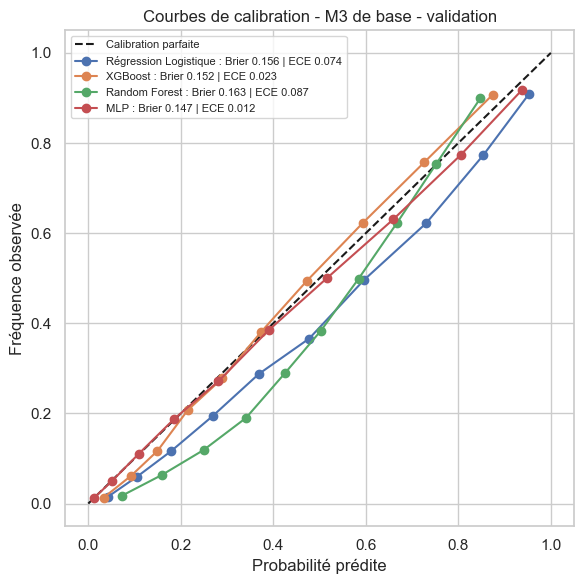

In [18]:

print("=== DeLong — p-values des différences d'AUC sur validation — modèles M3 de base ===")
df_delong = matrice_delong(dict_proba_val, y_val)
display(df_delong)
print('Rappel : 6 comparaisons par paires → seuil Bonferroni indicatif = 0.05/6 ≈ 0.0083')

print('\n=== Calibration — Brier score sur validation — modèles M3 de base ===')
df_calibration, courbes_calibration = evaluer_calibration(dict_proba_val, y_val)
display(df_calibration)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Calibration parfaite')
_brier_par_modele = df_calibration.set_index('Algorithme')['Brier'].to_dict()
_ece_par_modele   = (df_calibration.set_index('Algorithme')['ECE'].to_dict()
                     if 'ECE' in df_calibration.columns else {})
for nom, (xp, yp) in courbes_calibration.items():
    _b, _e = _brier_par_modele.get(nom), _ece_par_modele.get(nom)
    if _b is not None and _e is not None:
        _lab = f'{nom} : Brier {_b:.3f} | ECE {_e:.3f}'
    elif _b is not None:
        _lab = f'{nom} : Brier {_b:.3f}'
    else:
        _lab = nom
    plt.plot(xp, yp, marker='o', label=_lab)
plt.xlabel('Probabilité prédite')
plt.ylabel('Fréquence observée')
plt.title('Courbes de calibration - M3 de base - validation', fontweight='normal')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_calibration_m3_base_avec.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Évaluation finale sur le test interne


In [19]:
#  Évaluation finale sur le test interne, jamais utilisé pour sélectionner modèle + seuil.
#  Le seuil clinique a été choisi sur la validation, puis figé ici.

# Métriques au seuil standard 0.5
y_pred_m3_05 = (y_proba_m3_opt >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_m3_05).ravel()

se_05  = safe_div(tp, tp + fn)
sp_05  = safe_div(tn, tn + fp)
vpp_05 = safe_div(tp, tp + fp)
vpn_05 = safe_div(tn, tn + fn)
auc_final   = roc_auc_score(y_test, y_proba_m3_opt)
brier_final = brier_score_loss(y_test, y_proba_m3_opt)
bacc_final  = balanced_accuracy_score(y_test, y_pred_m3_05)

print('=' * 70)
print('MODÈLE FINAL — TEST INTERNE — MÉTRIQUES AU SEUIL 0.5')
print('=' * 70)
print(f'  Algorithme    : {algo_opt}')
print(f'  AUC           : {auc_final:.4f}')
print(f'  Brier score   : {brier_final:.4f}')
print(f'  Sensibilité   : {se_05:.4f}')
print(f'  Spécificité   : {sp_05:.4f}')
print(f'  VPP           : {vpp_05:.4f}')
print(f'  VPN           : {vpn_05:.4f}')
print(f'  Balanced Acc  : {bacc_final:.4f}')
print(f'  VP={tp:,} | VN={tn:,} | FP={fp:,} | FN={fn:,}')

# Seuil clinique figé sur la validation : application unique au test.
y_pred_m3_90 = (y_proba_m3_opt >= seuil_90).astype(int)
tn90, fp90, fn90, tp90 = confusion_matrix(y_test, y_pred_m3_90).ravel()
se_90  = safe_div(tp90, tp90 + fn90)
sp_90  = safe_div(tn90, tn90 + fp90)
vpp_90 = safe_div(tp90, tp90 + fp90)
vpn_90 = safe_div(tn90, tn90 + fn90)

print('\n=== TEST INTERNE — SEUIL CLINIQUE FIGÉ SUR VALIDATION ===')
print(f'  Seuil alerte   : {seuil_alerte:.3f}')
print(f'  Seuil fort     : {seuil_fort:.3f}')
print(f'  Sensibilité    : {se_90:.1%}')
print(f'  Spécificité    : {sp_90:.1%}')
print(f'  FP/100         : {fp90 / len(y_test) * 100:.1f}')
print(f'  FN/100         : {fn90 / len(y_test) * 100:.1f}')
print(f'  FN évités vs 0.5 : {fn - fn90:,}')
print(f'  Surcharge FP vs 0.5 : +{fp90 - fp:,}')
print(f'\nSeuils figés pour la validation temporelle : alerte={seuil_alerte:.3f} | fort={seuil_fort:.3f}')


MODÈLE FINAL — TEST INTERNE — MÉTRIQUES AU SEUIL 0.5
  Algorithme    : MLP
  AUC           : 0.8624
  Brier score   : 0.1458
  Sensibilité   : 0.6898
  Spécificité   : 0.8455
  VPP           : 0.7336
  VPN           : 0.8155
  Balanced Acc  : 0.7677
  VP=16,450 | VN=32,692 | FP=5,975 | FN=7,396

=== TEST INTERNE — SEUIL CLINIQUE FIGÉ SUR VALIDATION ===
  Seuil alerte   : 0.241
  Seuil fort     : 0.650
  Sensibilité    : 90.2%
  Spécificité    : 61.0%
  FP/100         : 24.1
  FN/100         : 3.7
  FN évités vs 0.5 : 5,062
  Surcharge FP vs 0.5 : +9,105

Seuils figés pour la validation temporelle : alerte=0.241 | fort=0.650


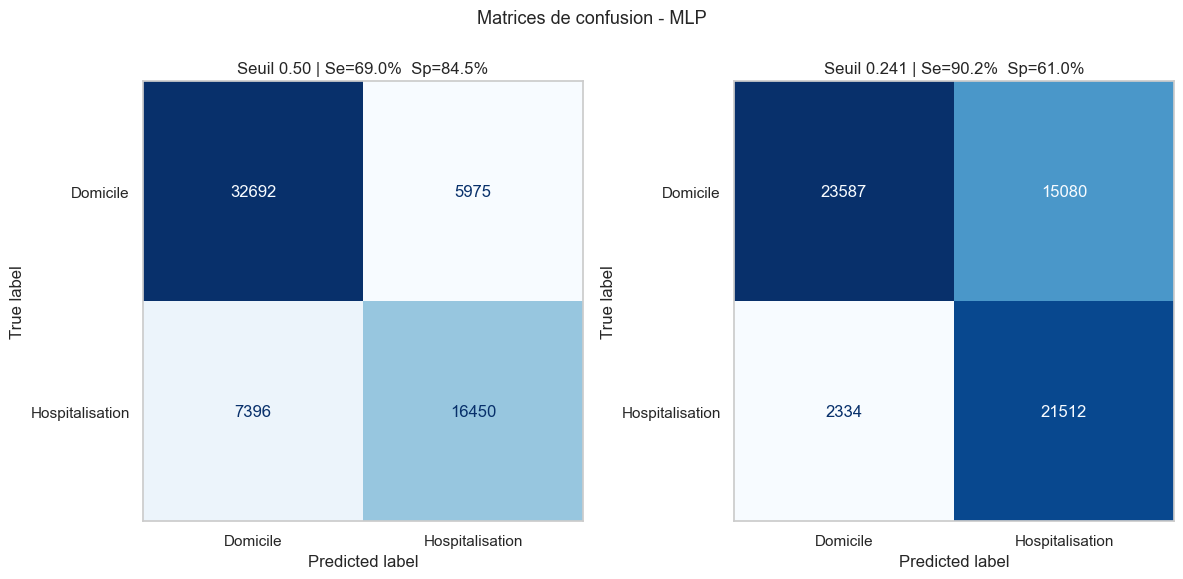

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_m3_05),
    display_labels=['Domicile', 'Hospitalisation']
).plot(ax=axes[0], colorbar=False, cmap='Blues', values_format='d')
axes[0].set_title(f'Seuil 0.50 | Se={se_05:.1%}  Sp={sp_05:.1%}', fontweight='normal')
axes[0].grid(False)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_m3_90),
    display_labels=['Domicile', 'Hospitalisation']
).plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='d')
axes[1].set_title(f'Seuil {seuil_90:.3f} | Se={se_90:.1%}  Sp={sp_90:.1%}', fontweight='normal')
axes[1].grid(False)

plt.suptitle(f'Matrices de confusion - {algo_opt}', fontsize=13, fontweight='normal')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig11_confusion_matrix_avec.png', dpi=150, bbox_inches='tight')
plt.show()


Régression Logistique        | AUC test = 0.8539 | N utilisé = 62,513 | NaN retirés = 0
XGBoost                      | AUC test = 0.8516 | N utilisé = 62,513 | NaN retirés = 0
Random Forest                | AUC test = 0.8495 | N utilisé = 62,513 | NaN retirés = 0
MLP                          | AUC test = 0.8624 | N utilisé = 62,513 | NaN retirés = 0
Comparateur ESI seul         | AUC test = 0.6922 | N utilisé = 62,513 | NaN retirés = 0


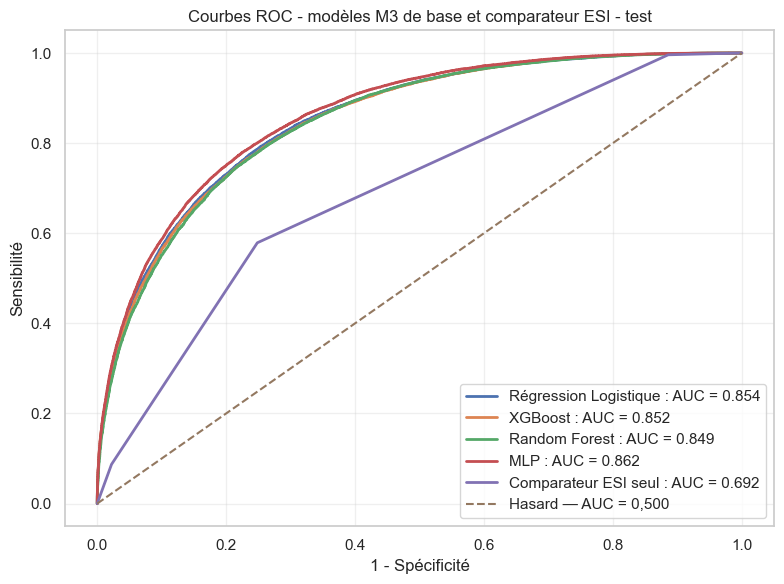

In [21]:
# Courbes ROC des modèles M3 et du comparateur ESI
out_path = FIG_DIR / "fig12_roc_m3_base_esi_avec.png"

# Probabilités TEST des modèles M3 de base.
roc_models = {
    "Régression Logistique": y_proba_rl_m3_base_test,
    "XGBoost":              y_proba_xgb_m3_base_test,
    "Random Forest":        y_proba_rf_m3_base_test,
    "MLP":                  y_proba_mlp_m3_base_test,
}

# Comparateur ESI : 1 = plus grave, 5 = moins grave.
# On inverse donc le score pour que valeur élevée = risque plus élevé.
if "acuity" in df_test.columns:
    y_score_esi = 6 - pd.to_numeric(df_test["acuity"], errors="coerce")
elif "esi" in df_test.columns:
    y_score_esi = 6 - pd.to_numeric(df_test["esi"], errors="coerce")
else:
    y_score_esi = None

if y_score_esi is not None:
    roc_models["Comparateur ESI seul"] = y_score_esi

# Tracé des courbes ROC avec gestion des NaN.
y_true_all = np.asarray(y_test)

plt.figure(figsize=(8, 6))

for model_name, y_score in roc_models.items():
    y_score = np.asarray(y_score, dtype=float)

    # On retire uniquement les lignes non exploitables pour ce modèle.
    mask = np.isfinite(y_true_all) & np.isfinite(y_score)

    y_true_clean = y_true_all[mask]
    y_score_clean = y_score[mask]

    n_removed = len(y_true_all) - len(y_true_clean)

    auc_value = roc_auc_score(y_true_clean, y_score_clean)
    fpr, tpr, _ = roc_curve(y_true_clean, y_score_clean)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} : AUC = {auc_value:.3f}"
    )

    print(
        f"{model_name:<28} | AUC test = {auc_value:.4f} | "
        f"N utilisé = {len(y_true_clean):,} | NaN retirés = {n_removed:,}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Hasard — AUC = 0,500"
)

plt.xlabel("1 - Spécificité")
plt.ylabel("Sensibilité")
plt.title("Courbes ROC - modèles M3 de base et comparateur ESI - test")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()


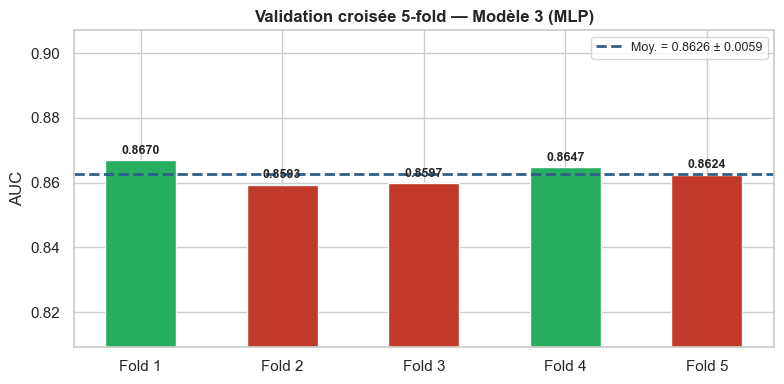

Stabilité CV (MLP) : 0.8626 ± 0.0059
  Fold 1 : 0.8670  (+0.0043)
  Fold 2 : 0.8593  (-0.0033)
  Fold 3 : 0.8597  (-0.0029)
  Fold 4 : 0.8647  (+0.0021)
  Fold 5 : 0.8624  (-0.0002)


In [22]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    clone(model_m3_opt), X_train_m3, y_train,
    cv=sgkf, groups=df_train['subject_id'], scoring='roc_auc', n_jobs=1
)

fig, ax = plt.subplots(figsize=(8, 4))
colors_cv = [VERT if s >= cv_scores.mean() else ROUGE for s in cv_scores]
ax.bar(range(1, 6), cv_scores, color=colors_cv, edgecolor='white', width=0.5)
ax.axhline(cv_scores.mean(), color=BLEU, lw=2, linestyle='--',
           label=f'Moy. = {cv_scores.mean():.4f} ± {2*cv_scores.std():.4f}')
for i, s in enumerate(cv_scores, 1):
    ax.text(i, s + 0.002, f'{s:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_ylim(max(0.5, cv_scores.min()-0.05), min(1.0, cv_scores.max()+0.04))
ax.set_ylabel('AUC')
ax.set_title(f'Validation croisée 5-fold — Modèle 3 ({algo_opt})', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig13_cv5_folds_avec.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Stabilité CV ({algo_opt}) : {cv_scores.mean():.4f} ± {2*cv_scores.std():.4f}')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i} : {s:.4f}  ({s - cv_scores.mean():+.4f})')


In [23]:
# Diagnostic overfitting — gap AUC train / test

auc_train = roc_auc_score(y_train, model_m3_opt.predict_proba(X_train_m3)[:, 1])
auc_test  = roc_auc_score(y_test,  y_proba_m3_opt)
gap       = auc_train - auc_test

if gap > 0.10:
    diagnostic = f"OVERFITTING détecté: gap = {gap:.3f}"
elif gap > 0.05:
    diagnostic = f"Gap modéré ({gap:.3f}) :à surveiller"
else:
    diagnostic = f"Pas d'overfitting significatif: gap = {gap:.3f}"

print(f"AUC train : {auc_train:.4f}")
print(f"AUC test  : {auc_test:.4f}")
print(f"Gap       : {gap:.4f}")
print(f"→ {diagnostic}")


AUC train : 0.8814
AUC test  : 0.8624
Gap       : 0.0189
→ Pas d'overfitting significatif: gap = 0.019


In [24]:
metrics_final = pd.DataFrame([
    {'Modele_retenu': algo_opt, 'Jeu': 'test_interne', 'Type_seuil': 'standard_0.5', 'Seuil': 0.5,
     'AUC': auc_final, 'Brier': brier_final,
     'Se': se_05,  'Sp': sp_05,  'VPP': vpp_05,  'VPN': vpn_05,
     'VP': tp,   'VN': tn,   'FP': fp,   'FN': fn},
    {'Modele_retenu': algo_opt, 'Jeu': 'test_interne', 'Type_seuil': 'se_clin_90_val', 'Seuil': seuil_90,
     'AUC': auc_final, 'Brier': brier_final,
     'Se': se_90,  'Sp': sp_90,  'VPP': vpp_90,  'VPN': vpn_90,
     'VP': tp90, 'VN': tn90, 'FP': fp90, 'FN': fn90},
])
metrics_final['Balanced_Accuracy'] = (
    metrics_final['Se'] + metrics_final['Sp']
) / 2
metrics_final.to_csv(RESULT_DIR / 'metrics_meilleur_modele.csv', index=False)
print('metrics_meilleur_modele.csv sauvegardé')
display(metrics_final)


metrics_meilleur_modele.csv sauvegardé


,Modele_retenu,Jeu,Type_seuil,Seuil,AUC,Brier,Se,Sp,VPP,VPN,VP,VN,FP,FN,Balanced_Accuracy
0,MLP,test_interne,standard_0.5,0.500,0.862423,0.145767,0.689843,0.845475,0.733556,0.815506,16450,32692,5975,7396,0.767659
1,MLP,test_interne,se_clin_90_val,0.241,0.862423,0.145767,0.902122,0.610003,0.587888,0.909957,21512,23587,15080,2334,0.756063


In [25]:
# Préparation du modèle final en mémoire pour la validation temporelle
# Le modèle, le scaler, l'imputer et le TF-IDF viennent des cellules précédentes.
# On ne recharge pas d'artefacts depuis le disque : le notebook suit un flux unique.

model = model_m3_opt
scaler = scaler_m3
features_baseline = list(feats_m3)
features = features_baseline
model_type = algo_opt

auc_nb03_test = float(auc_final)
auc_nb03_selection = float(best_row_opt['AUC'])
auc_nb03 = auc_nb03_test
bacc_nb03 = float(bacc_final)
brier_nb03 = float(brier_final)
valid_period = VALID_PERIOD
selection_criterion = f'Spécificité maximale sous contrainte Se >= {SE_CIBLE:.0%} sur validation interne'

train_medians = pd.Series({
    col: float(df_train[col].median())
    for col in feats_m3 if col in df_train.columns
})

meta = {
    'model_name': f'Modèle 3 — Variables structurées NB01 + NLP ({algo_opt})',
    'algo_opt': algo_opt,
    'selection_criterion': selection_criterion,
    'feature_policy': 'Conservation de toutes les colonnes NB01 dans df ; exclusion des identifiants/dates brutes/cible/texte des prédicteurs structurés ; catégorielles NB01 encodées en dummies.',
    'nb01_columns_expected': NB01_EXPECTED_COLUMNS,
    'nb01_columns_loaded': [c for c in NB01_EXPECTED_COLUMNS if c in df.columns],
    'nb01_columns_absent': [c for c in NB01_EXPECTED_COLUMNS if c not in df.columns],
    'traceability_columns': TRACEABILITY_COLS,
    'categorical_raw_features': NB01_CATEGORICAL_RAW,
    'categorical_encoded_features': CAT_ENCODED_COLS,
    'age_variable_used': AGE_COL,
    'charlson_variable_used': CHARLSON_COL if 'CHARLSON_COL' in globals() else None,
    'charlson_priority': 'charlson_score puis charlson_score_simplifie en secours',
    'features_m1': features_m1,
    'features_m2': [f for f in features_m2 if f in df.columns],
    'features_m3': features_baseline,
    'tfidf_features': tfidf.get_feature_names_out().tolist(),
    'auc_validation_selection': auc_nb03_selection,
    'auc_final_test': auc_nb03_test,
    'balanced_accuracy_final_05': bacc_nb03,
    'brier_final_test': brier_nb03,
    'random_state': RANDOM_STATE,
    'uses_nlp': True,
    'text_column_used': 'cleaned_complaint',
    'target': TARGET,
    'threshold_default': 0.5,
    'seuil_alerte': float(seuil_alerte),
    'seuil_fort': float(seuil_fort),
    'valid_period': VALID_PERIOD,
    'split_policy': 'train/validation/test patient-level disjoints dans le pool avant validation temporelle',
    'train_medians': train_medians.to_dict(),
}

print('Modèle final préparé en mémoire')
print(f'Algorithme retenu : {model_type}')
print(f'Features structurées : {len(features_baseline)}')
print(f'Seuil alerte : {seuil_alerte:.3f} | seuil fort : {seuil_fort:.3f}')
print(f'Période validation temporelle : {VALID_PERIOD}')


Modèle final préparé en mémoire
Algorithme retenu : MLP
Features structurées : 32
Seuil alerte : 0.241 | seuil fort : 0.650
Période validation temporelle : 2017 - 2019


## 9. Validation temporelle


In [26]:
# Cohorte de validation temporelle
# La cohorte récente a été isolée dans la section de split et n'a pas servi à entraîner le modèle.
if len(df_valid_temp) == 0:
    raise ValueError('Validation temporelle vide — vérifier VALID_PERIOD et anchor_year_group')

# Alias unique pour les cellules de validation temporelle qui suivent.
# df_valid_temp est le nom issu du split ; df_val_temp est utilisé dans les cellules d'évaluation.
df_val_temp = df_valid_temp
y_val = df_val_temp[TARGET].values

print(f'Validation temporelle : {len(df_val_temp):,} séjours | hospit. : {y_val.mean()*100:.1f}%')
print(f'Critère de sélection interne : {selection_criterion}')
print(f'AUC sélection interne : {auc_nb03_selection:.4f}')
print(f'AUC test interne      : {auc_nb03_test:.4f}')
print(f'Brier test interne    : {brier_nb03:.4f}')
print(f'features_baseline     : {len(features_baseline)} variables')


Validation temporelle : 67,963 séjours | hospit. : 38.9%
Critère de sélection interne : Spécificité maximale sous contrainte Se >= 90% sur validation interne
AUC sélection interne : 0.8605
AUC test interne      : 0.8624
Brier test interne    : 0.1458
features_baseline     : 32 variables


In [27]:
#  Garde-fou : vérifications avant tout calcul (anti-bug silencieux) 
_erreurs, _alertes = [], []

# Harmonisation du nom de la cohorte de validation temporelle.
# Certaines cellules amont utilisent df_valid_temp ; les cellules d'évaluation utilisent df_val_temp.
if 'df_val_temp' not in globals() and 'df_valid_temp' in globals():
    df_val_temp = df_valid_temp


# Helper local : reproduit l'encodage NB03 pour vérifier les colonnes attendues.
def _normaliser_modalite_prediction(s):
    return (
        s.fillna('missing')
         .astype(str)
         .str.strip()
         .str.lower()
         .str.replace(r'[^a-z0-9]+', '_', regex=True)
         .str.strip('_')
         .replace('', 'missing')
    )

def _add_nb01_prediction_dummies(df_input, meta=None):
    df_out = df_input.copy()
    raw_cats = (meta or {}).get('categorical_raw_features', ['gender', 'arrival_transport'])
    for col in raw_cats:
        if col in df_out.columns:
            s = _normaliser_modalite_prediction(df_out[col])
            dummies = pd.get_dummies(s, prefix=col, dtype='int8')
            old_dummy_cols = [c for c in df_out.columns if c.startswith(f'{col}_')]
            if old_dummy_cols:
                df_out = df_out.drop(columns=old_dummy_cols)
            df_out = pd.concat([df_out, dummies], axis=1)
    return df_out

# 1) Seuils cliniques réellement présents dans les métadonnées NB03 ?
if 'seuil_alerte' not in meta:
    _alertes.append(f"meta['seuil_alerte'] ABSENT -> seuil par défaut {seuil_alerte:.3f} utilisé. "
                    "Relancer NB03 corrigé pour figer le vrai seuil avant d'interpréter la validation temporelle.")
if 'seuil_fort' not in meta:
    _alertes.append(f"meta['seuil_fort'] absent -> valeur par défaut {seuil_fort:.3f}.")

# 2) Colonne texte attendue par build_X / 3) cible présente
if 'cleaned_complaint' not in df.columns:
    _erreurs.append("Colonne 'cleaned_complaint' absente -> build_X plantera (TF-IDF).")
if TARGET not in df.columns:
    _erreurs.append(f"Cible '{TARGET}' absente de la cohorte.")

# 4) Colonnes attendues par le scaler après reconstruction des dummies NB01.
_scaler_cols = list(getattr(scaler, 'feature_names_in_', features_baseline))
df_guard = _add_nb01_prediction_dummies(df, meta)
_manq = [c for c in _scaler_cols if c not in df_guard.columns]
if _manq:
    _alertes.append(f"{len(_manq)} colonne(s) attendue(s) par le scaler absente(s) même après encodage -> "
                    f"comblées par 0 : {[str(c) for c in _manq[:8]]}{'...' if len(_manq) > 8 else ''}")

# 5) Cohérence du nombre de features (info)
_n_attendu = len(features_baseline) + len(tfidf.get_feature_names_out())
print(f"Features attendues (structurées + TF-IDF) : {_n_attendu}")
print(f"Validation temporelle : {len(df_val_temp):,} séjours | "
      f"prévalence {df_val_temp[TARGET].mean()*100:.1f}%")
for _a in _alertes:
    print('⚠', _a)
if _erreurs:
    raise RuntimeError('Garde-fou validation temporelle (bloquant) - ' + ' | '.join(_erreurs))
print('Garde-fou : aucune erreur bloquante')

Features attendues (structurées + TF-IDF) : 1032
Validation temporelle : 67,963 séjours | prévalence 38.9%
Garde-fou : aucune erreur bloquante


In [28]:
#  Reconstruction de la matrice X comme dans NB03 
def _normaliser_modalite_prediction(s):
    return (
        s.fillna('missing')
         .astype(str)
         .str.strip()
         .str.lower()
         .str.replace(r'[^a-z0-9]+', '_', regex=True)
         .str.strip('_')
         .replace('', 'missing')
    )

def _add_nb01_prediction_dummies(df_input, meta=None):
    """Reproduit l'encodage des variables catégorielles NB01 avant prédiction."""
    df_out = df_input.copy()
    raw_cats = (meta or {}).get('categorical_raw_features', ['gender', 'arrival_transport'])
    for col in raw_cats:
        if col in df_out.columns:
            s = _normaliser_modalite_prediction(df_out[col])
            dummies = pd.get_dummies(s, prefix=col, dtype='int8')
            old_dummy_cols = [c for c in df_out.columns if c.startswith(f'{col}_')]
            if old_dummy_cols:
                df_out = df_out.drop(columns=old_dummy_cols)
            df_out = pd.concat([df_out, dummies], axis=1)
    return df_out


def build_X(df_input, features_model, scaler, tfidf=None, imputer=None, t_medians=None):
    """Recrée les dummies NB01, aligne les colonnes, impute, scale, puis ajoute le TF-IDF."""
    
    df_work = _add_nb01_prediction_dummies(df_input, meta if 'meta' in globals() else None)
    
    scaler_cols = list(scaler.feature_names_in_) if hasattr(scaler, 'feature_names_in_') else list(features_model)
    df_scaled = df_work.reindex(columns=scaler_cols, fill_value=0)
    df_scaled = df_scaled.apply(pd.to_numeric, errors='coerce')

    if imputer is not None and hasattr(imputer, 'statistics_'):
        imp_cols = list(imputer.feature_names_in_) if hasattr(imputer, 'feature_names_in_') else scaler_cols
        # Colonnes absentes après reindex : 0 pour les dummies non observées, puis imputation pour valeurs manquantes réelles.
        df_imp = df_scaled.reindex(columns=imp_cols, fill_value=0)
        df_imp = df_imp.apply(pd.to_numeric, errors='coerce')
        X_imp = imputer.transform(df_imp)
        df_scaled = pd.DataFrame(X_imp, columns=imp_cols, index=df_scaled.index).reindex(columns=scaler_cols, fill_value=0)
    elif t_medians is not None and len(t_medians) > 0:
        for col in scaler_cols:
            if df_scaled[col].isna().any():
                df_scaled[col] = df_scaled[col].fillna(float(t_medians.get(col, df_scaled[col].median())))
    else:
        df_scaled = df_scaled.fillna(df_scaled.median(numeric_only=True))

    X_num = scaler.transform(df_scaled[scaler_cols])
    if tfidf is None:
        return csr_matrix(X_num)

    X_text = tfidf.transform(df_input['cleaned_complaint'].fillna(''))
    return sp_hstack([csr_matrix(X_num), X_text]).tocsr()


def predict_proba_safe(model, X):
    """Prédiction robuste : MLP en dense, autres modèles en sparse si possible."""
    if type(model).__name__ == 'MLPClassifier' and issparse(X):
        X = X.toarray()
    try:
        return model.predict_proba(X)[:, 1]
    except (TypeError, ValueError):
        return model.predict_proba(X.toarray() if issparse(X) else X)[:, 1]


# Test rapide
X_test_small = build_X(df_val_temp.head(10), features_baseline, scaler, tfidf, imputer, train_medians)
print(f'build_X OK  — shape : {X_test_small.shape}')

build_X OK  — shape : (10, 1032)


In [29]:
#  Prédictions sur la validation temporelle 
print('Construction de X_val...')
X_val = build_X(df_val_temp, features_baseline, scaler, tfidf, imputer, train_medians)
y_proba = predict_proba_safe(model, X_val)

print(f'X_val shape : {X_val.shape}')
print(f'y_proba — min={y_proba.min():.3f}  max={y_proba.max():.3f}  mean={y_proba.mean():.3f}')
print(f'Prévalence observée validation : {df_val_temp[TARGET].mean():.3f}')

if y_proba.mean() > 0.9 or y_proba.mean() < 0.05:
    print('⚠ Probas atypiques — vérifier cohérence du pipeline')
else:
    print('Distribution des probabilités')

feature_names = features_baseline + list(tfidf.get_feature_names_out())
print(f'Features attendues : {len(feature_names)}')


Construction de X_val...
X_val shape : (67963, 1032)
y_proba — min=0.000  max=1.000  mean=0.381
Prévalence observée validation : 0.389
Distribution des probabilités
Features attendues : 1032


In [30]:
#  Résultats principaux — validation temporelle
# sur la validation interne, puis appliqué tel quel à la validation temporelle.
def safe_div(a, b):
    return a / b if b > 0 else 0

# Le seuil clinique interne est appliqué sans réajustement.
y_pred_05 = (y_proba >= 0.5).astype(int)
y_pred = (y_proba >= seuil_alerte).astype(int)

def _metrics_at_threshold(y_true, y_score, y_hat, seuil, type_seuil):
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    n_total = len(y_true)
    se  = safe_div(tp, tp + fn)
    sp  = safe_div(tn, tn + fp)
    vpp = safe_div(tp, tp + fp)
    vpn = safe_div(tn, tn + fn)
    return {
        'Modele': model_type,
        'Jeu': 'validation_temporelle',
        'Type_seuil': type_seuil,
        'Seuil': float(seuil),
        'N': int(n_total),
        'Admissions': int(tp + fn),
        'AUC': roc_auc_score(y_true, y_score),
        'Brier': brier_score_loss(y_true, y_score),
        'Se': se,
        'Sp': sp,
        'VPP': vpp,
        'VPN': vpn,
        'VP': int(tp),
        'VN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'Balanced_Accuracy': (se + sp) / 2,
        'Alertes/100': (tp + fp) / n_total * 100,
        'VP/100': tp / n_total * 100,
        'VN/100': tn / n_total * 100,
        'FP/100': fp / n_total * 100,
        'FN/100': fn / n_total * 100,
    }

m_05 = _metrics_at_threshold(y_val, y_proba, y_pred_05, 0.5, 'standard_0.5')
m_clin = _metrics_at_threshold(y_val, y_proba, y_pred, seuil_alerte, 'seuil_clinique_interne')

# Variables utilisées dans le reste du notebook = seuil clinique NB03.
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
sensibilite = m_clin['Se']
specificite = m_clin['Sp']
vpp = m_clin['VPP']
vpn = m_clin['VPN']
auc = m_clin['AUC']

# Comparaison avec le test interne NB03 : différence temporelle - test interne.
delta = auc - auc_nb03 if not np.isnan(auc_nb03) else np.nan
if np.isnan(delta):
    interpretation = 'comparaison test interne non disponible'
elif abs(delta) < 0.03:
    interpretation = 'stabilité acceptable'
elif delta > 0.03:
    interpretation = 'performance supérieure — vérifier indépendance ⚠'
else:
    interpretation = 'dégradation temporelle à documenter ⚠'

print('=' * 65)
print('RÉSULTATS — VALIDATION TEMPORELLE')
print('=' * 65)
print(f'  Modèle       : {model_type}')
print(f'  AUC          : {auc:.4f}')
print(f'  Brier        : {m_clin["Brier"]:.4f}')
print(f'  Seuil clinique interne : {seuil_alerte:.3f}')
print(f'  Sensibilité  : {sensibilite:.4f}')
print(f'  Spécificité  : {specificite:.4f}')
print(f'  VPP          : {vpp:.4f}')
print(f'  VPN          : {vpn:.4f}')
print(f'  VP={tp:,} | VN={tn:,} | FP={fp:,} | FN={fn:,}')
print(f'  Alertes/100={m_clin["Alertes/100"]:.1f} | VP/100={m_clin["VP/100"]:.1f} | FP/100={m_clin["FP/100"]:.1f} | FN/100={m_clin["FN/100"]:.1f}')
print(f'  AUC test interne NB03 : {auc_nb03:.4f}' if not np.isnan(auc_nb03) else '  AUC test interne NB03 : non disponible')
print(f'  Écart validation temporelle - test interne : {delta:+.4f} → {interpretation}' if not np.isnan(delta) else f'  Écart validation temporelle - test interne : {interpretation}')

print('\nRéférence au seuil 0,5, conservée seulement pour comparaison :')
print(f'  Se={m_05["Se"]:.4f} | Sp={m_05["Sp"]:.4f} | FP/100={m_05["FP/100"]:.1f} | FN/100={m_05["FN/100"]:.1f}')

metrics_validation_temporelle = pd.DataFrame([m_05, m_clin])
metrics_validation_temporelle.to_csv(RESULT_DIR / 'metrics_validation_temporelle.csv', index=False)
print('\nmetrics_validation_temporelle.csv sauvegardé')


RÉSULTATS — VALIDATION TEMPORELLE
  Modèle       : MLP
  AUC          : 0.8881
  Brier        : 0.1313
  Seuil clinique interne : 0.241
  Sensibilité  : 0.8911
  Spécificité  : 0.6862
  VPP          : 0.6441
  VPN          : 0.9081
  VP=23,572 | VN=28,485 | FP=13,025 | FN=2,881
  Alertes/100=53.8 | VP/100=34.7 | FP/100=19.2 | FN/100=4.2
  AUC test interne NB03 : 0.8624
  Écart validation temporelle - test interne : +0.0257 → stabilité acceptable

Référence au seuil 0,5, conservée seulement pour comparaison :
  Se=0.7090 | Sp=0.8762 | FP/100=7.6 | FN/100=11.3

metrics_validation_temporelle.csv sauvegardé


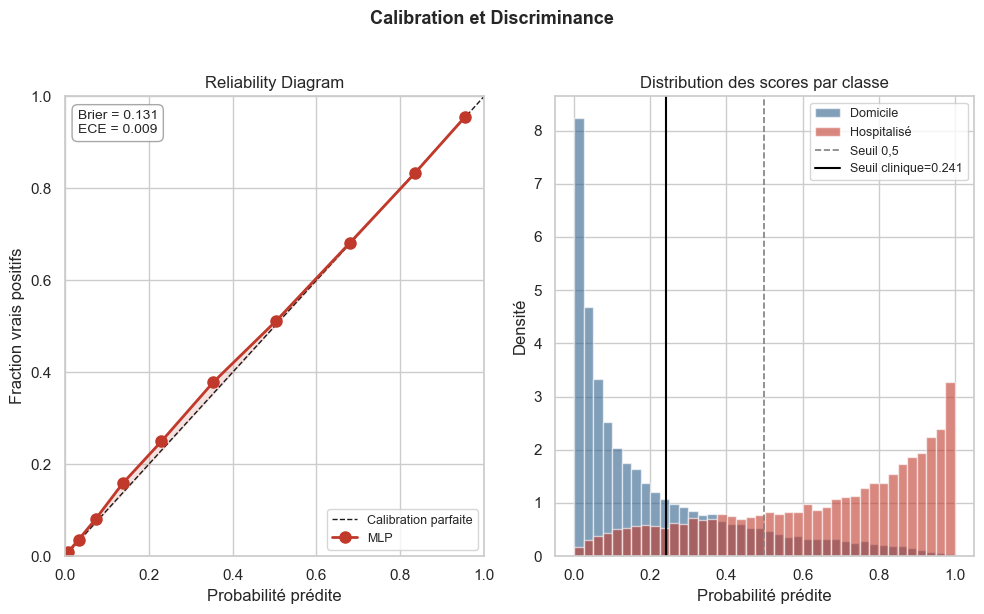

Score de Brier : 0.1313  (0=parfait | 0.25≈référence grossière si prévalence équilibrée)
ECE déciles : 0.0091
Calibration : Acceptable


,decile,n,proba_moyenne,taux_observe,ecart
0,"(-0.0009925700000000001, 0.0169]",6797,0.007166,0.008827,0.001661
1,"(0.0169, 0.0493]",6796,0.032362,0.035903,0.003542
2,"(0.0493, 0.101]",6796,0.072904,0.080636,0.007732
3,"(0.101, 0.178]",6796,0.137538,0.158328,0.020791
4,"(0.178, 0.288]",6797,0.229615,0.249375,0.019760
5,"(0.288, 0.423]",6796,0.353203,0.377869,0.024666
6,"(0.423, 0.59]",6796,0.504081,0.512066,0.007985
7,"(0.59, 0.762]",6796,0.678827,0.680695,0.001867
8,"(0.762, 0.9]",6796,0.834560,0.832696,-0.001864
9,"(0.9, 1.0]",6797,0.954801,0.955863,0.001062


tab3_calibration_deciles_avec.csv sauvegardé
tables/tab4_calibration_deciles_avec_op.csv sauvegardé


In [31]:
# Métriques de calibration calculées AVANT le tracé, afin d'être annotées sur la figure.
brier = brier_score_loss(y_val, y_proba)
_calib_pre = pd.DataFrame({'y_true': y_val, 'y_proba': y_proba})
_calib_pre['decile'] = pd.qcut(_calib_pre['y_proba'], 10, duplicates='drop')
_agg_pre = (_calib_pre.groupby('decile', observed=True)
            .agg(n=('y_true', 'size'),
                 proba_moyenne=('y_proba', 'mean'),
                 taux_observe=('y_true', 'mean')))
ece = float((_agg_pre['n'] * (_agg_pre['taux_observe'] - _agg_pre['proba_moyenne']).abs()).sum()
            / _agg_pre['n'].sum())

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

prob_true, prob_pred = calibration_curve(y_val, y_proba, n_bins=10, strategy='quantile')
axes[0].plot([0,1],[0,1],'k--',lw=1, label='Calibration parfaite')
axes[0].plot(prob_pred, prob_true, 'o-', lw=2, color='#C0392B', markersize=8,
             label=model_type)
axes[0].fill_between(prob_pred, prob_pred, prob_true, alpha=0.15, color='#C0392B')
axes[0].set(xlabel='Probabilité prédite', ylabel='Fraction vrais positifs',
            title='Reliability Diagram', xlim=[0,1], ylim=[0,1])
axes[0].legend(fontsize=9)
axes[0].text(0.03, 0.97, f'Brier = {brier:.3f}\nECE = {ece:.3f}',
             transform=axes[0].transAxes, va='top', ha='left', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       alpha=0.85, edgecolor='#999999'))

for tgt, color, label in [(0,'#2E5F8A','Domicile'), (1,'#C0392B','Hospitalisé')]:
    axes[1].hist(y_proba[y_val==tgt], bins=40, alpha=0.6, color=color,
                 edgecolor='white', density=True, label=label)
axes[1].axvline(0.5, color='grey', linestyle='--', lw=1.2, label='Seuil 0,5')
axes[1].axvline(seuil_alerte, color='black', linestyle='-', lw=1.5, label=f'Seuil clinique={seuil_alerte:.3f}')
axes[1].set(xlabel='Probabilité prédite', ylabel='Densité',
            title='Distribution des scores par classe')
axes[1].legend(fontsize=9)

plt.suptitle('Calibration et Discriminance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig14_calibration_avec.png', dpi=150, bbox_inches='tight')
plt.show()

brier = brier_score_loss(y_val, y_proba)
print(f'Score de Brier : {brier:.4f}  (0=parfait | 0.25≈référence grossière si prévalence équilibrée)')

# Table de calibration par déciles : indispensable si l'application affiche une probabilité.
calib_df = pd.DataFrame({'y_true': y_val, 'y_proba': y_proba})
calib_df['decile'] = pd.qcut(calib_df['y_proba'], 10, duplicates='drop')

table_calib = (
    calib_df.groupby('decile', observed=True)
    .agg(
        n=('y_true', 'size'),
        proba_moyenne=('y_proba', 'mean'),
        taux_observe=('y_true', 'mean')
    )
    .reset_index()
)
table_calib['ecart'] = table_calib['taux_observe'] - table_calib['proba_moyenne']

ece = (table_calib['n'] * table_calib['ecart'].abs()).sum() / table_calib['n'].sum()
print(f'ECE déciles : {ece:.4f}')
print('Calibration : ' + ('Acceptable' if (brier < 0.15 and ece < 0.05) else '⚠ À vérifier'))

display(table_calib)
table_calib.to_csv(RESULT_DIR / 'tab3_calibration_deciles_avec.csv', index=False)
table_calib.to_csv(RESULT_DIR / 'tables' / 'tab4_calibration_deciles_avec_op.csv', index=False)
print('tab3_calibration_deciles_avec.csv sauvegardé')
print('tables/tab4_calibration_deciles_avec_op.csv sauvegardé')


In [32]:
# Recalibration Platt (sigmoid) exploration locale 
# cette cellule ajuste Platt sur la validation temporelle elle-même.
# Elle sert uniquement à documenter la calibration locale.
# Les métriques principales de validation ne doivent pas être recalculées
# sur ces probabilités ajustées, car cela utiliserait les labels de validation.

needs_calibration = (brier >= 0.15 or ece >= 0.05)

if needs_calibration:
    print('** Calibration insuffisante — application de la correction Platt')

    # Platt scaling manuel : régression logistique sur les scores bruts
    from sklearn.linear_model import LogisticRegression as _LR
    _platt = _LR(max_iter=1000, random_state=RANDOM_STATE)
    _platt.fit(y_proba.reshape(-1, 1), y_val)

    y_proba_cal = _platt.predict_proba(y_proba.reshape(-1, 1))[:, 1]
    calibrator  = _platt  # conservé pour la sauvegarde

    #  Métriques après calibration 
    brier_cal = brier_score_loss(y_val, y_proba_cal)
    prob_true_cal, prob_pred_cal = calibration_curve(
        y_val, y_proba_cal, n_bins=10, strategy='quantile'
    )

    calib_df_cal = pd.DataFrame({'y_true': y_val, 'y_proba': y_proba_cal})
    calib_df_cal['decile'] = pd.qcut(calib_df_cal['y_proba'], 10, duplicates='drop')
    table_calib_cal = (
        calib_df_cal.groupby('decile', observed=True)
        .agg(n=('y_true','size'), proba_moyenne=('y_proba','mean'), taux_observe=('y_true','mean'))
        .reset_index()
    )
    table_calib_cal['ecart'] = table_calib_cal['taux_observe'] - table_calib_cal['proba_moyenne']
    ece_cal = (table_calib_cal['n'] * table_calib_cal['ecart'].abs()).sum() / table_calib_cal['n'].sum()

    #  Figure comparative avant / après 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot([0,1],[0,1],'k--',lw=1, label='Calibration parfaite')
    axes[0].plot(prob_pred,     prob_true,     'o-', lw=2, color='#C0392B',
                 markersize=7, label=f'Avant (ECE={ece:.4f})')
    axes[0].plot(prob_pred_cal, prob_true_cal, 's-', lw=2, color='#27AE60',
                 markersize=7, label=f'Après Platt (ECE={ece_cal:.4f})')
    axes[0].fill_between(prob_pred_cal, prob_pred_cal, prob_true_cal,
                          alpha=0.12, color='#27AE60')
    axes[0].set(xlabel='Probabilité prédite', ylabel='Fraction observée',
                title='Reliability Diagram — avant vs après Platt',
                xlim=[0,1], ylim=[0,1])
    axes[0].legend(fontsize=9)

    axes[1].bar(['Avant Platt', 'Après Platt'], [brier, brier_cal],
                color=['#C0392B','#27AE60'], edgecolor='white', width=0.4)
    axes[1].axhline(0.15, color='grey', linestyle='--', lw=1,
                    label='Seuil acceptable (0.15)')
    axes[1].set_ylabel('Score de Brier')
    axes[1].set_title('Amélioration du Brier score')
    axes[1].legend(fontsize=9)
    for j, v in enumerate([brier, brier_cal]):
        axes[1].text(j, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
    plt.suptitle(f'Recalibration Platt — {model_type}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig15_calibration_platt_avec.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Brier avant : {brier:.4f}  →  après : {brier_cal:.4f}  (Δ={brier_cal-brier:+.4f})')
    print(f'ECE   avant : {ece:.4f}   →  après : {ece_cal:.4f}   (Δ={ece_cal-ece:+.4f})')
    verdict = 'Acceptable' if (brier_cal < 0.15 and ece_cal < 0.05) else 'Toujours imparfaite — documenter dans les limites'
    print(f'Verdict : {verdict}')

    # Sauvegarde uniquement exploratoire : ne pas utiliser comme modèle final.
    table_calib_cal.to_csv(RESULT_DIR / 'tab5_calibration_deciles_platt_avec.csv', index=False)
    print('tab5_calibration_deciles_platt_avec.csv sauvegardé')
    print('Aucun modèle calibré n’est sauvegardé ici : utiliser un jeu de calibration séparé, comme dans NB05.')

else:
    print('Calibration acceptable — recalibration Platt non nécessaire')
    calibrator  = None
    brier_cal   = brier
    ece_cal     = ece
    y_proba_cal = y_proba.copy()


Calibration acceptable — recalibration Platt non nécessaire


In [33]:
# Conservation des probabilités non calibrées pour la validation 
# On ne remplace pas y_proba par y_proba_cal ici.
# y_proba_cal est issu d'une recalibration exploratoire ajustée sur la validation
# temporelle elle-même ; l'utiliser pour les métriques principales serait optimiste.

y_proba_validation = y_proba.copy()
y_pred = (y_proba_validation >= seuil_alerte).astype(int)

# Recalcul des métriques principales avec les probabilités non recalibrées
# et le seuil clinique figé sur la validation interne.
auc = roc_auc_score(y_val, y_proba_validation)
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
sensibilite = safe_div(tp, tp + fn)
specificite = safe_div(tn, tn + fp)
vpp = safe_div(tp, tp + fp)
vpn = safe_div(tn, tn + fn)

label_cal = f'(non recalibré ; seuil clinique interne={seuil_alerte:.3f})'
print(f'Métriques de validation temporelle {label_cal} :')
print(f'  AUC={auc:.4f}  Se={sensibilite:.4f}  Sp={specificite:.4f}  FP/100={fp/len(y_val)*100:.1f}  FN/100={fn/len(y_val)*100:.1f}')


Métriques de validation temporelle (non recalibré ; seuil clinique interne=0.241) :
  AUC=0.8881  Se=0.8911  Sp=0.6862  FP/100=19.2  FN/100=4.2


In [34]:
# Sorties opérationnelles 
from sklearn.metrics import average_precision_score

TABLE_DIR = RESULT_DIR / 'tables'
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Probabilités de référence,non calibrées
y_proba_reference = y_proba_validation.copy() if 'y_proba_validation' in globals() else y_proba.copy()
y_true_reference = np.asarray(y_val, dtype=int)

ap = average_precision_score(y_true_reference, y_proba_reference)
brier_operationnel = brier_score_loss(y_true_reference, y_proba_reference)

# DataFrame de prédictions opérationnelles
colonnes_prediction = [
    'subject_id', 'stay_id', 'intime', 'anchor_year_group', 'ayg_start', TARGET,
    'age_ed', 'anchor_age', 'gender', 'acuity', 'arrival_transport', 'cleaned_complaint'
]
colonnes_prediction = [c for c in colonnes_prediction if c in df_val_temp.columns]
prediction_df = df_val_temp.loc[:, colonnes_prediction].copy()
prediction_df = prediction_df.loc[:, ~prediction_df.columns.duplicated()].copy()
prediction_df['proba_hospitalisation'] = y_proba_reference


def metriques_operationnelles(y, p, seuil):
    pred = (p >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    n_total = len(y)
    se = safe_div(tp, tp + fn)
    sp = safe_div(tn, tn + fp)
    vpp = safe_div(tp, tp + fp)
    vpn = safe_div(tn, tn + fn)
    return {
        'Seuil': float(seuil),
        'Alertes': int(tp + fp),
        'Admissions': int(tp + fn),
        'VP': int(tp), 'FP': int(fp), 'FN': int(fn), 'VN': int(tn),
        'Se': se, 'Sp': sp, 'VPP': vpp, 'VPN': vpn,
        'FNR': safe_div(fn, tp + fn),
        'FPR': safe_div(fp, tn + fp),
        'Alertes_pour_100_passages': (tp + fp) / n_total * 100,
        'VP_pour_100_passages': tp / n_total * 100,
        'FP_pour_100_passages': fp / n_total * 100,
        'FN_pour_100_passages': fn / n_total * 100,
    }

# Analyse multi-seuils identique à l'esprit NB07.
seuils_grille = sorted(set([0.05, 0.10, 0.15, 0.20, float(seuil_alerte), 0.30, 0.40, 0.50, float(seuil_fort), 0.75, 0.90]))
analyse_seuils = pd.DataFrame([metriques_operationnelles(y_true_reference, y_proba_reference, s) for s in seuils_grille])

resume_seuils = pd.DataFrame([
    {'Seuil_type': 'pré-alerte', **metriques_operationnelles(y_true_reference, y_proba_reference, seuil_alerte)},
    {'Seuil_type': 'standard',   **metriques_operationnelles(y_true_reference, y_proba_reference, 0.50)},
    {'Seuil_type': 'fort',       **metriques_operationnelles(y_true_reference, y_proba_reference, seuil_fort)},
])

# Classes de risque 
seuil_intermediaire = 0.50
if not (seuil_alerte < seuil_intermediaire < seuil_fort):
    seuil_intermediaire = (seuil_alerte + seuil_fort) / 2
bins = [0, seuil_alerte, seuil_intermediaire, seuil_fort, 1.0]
labels = ['faible', 'intermédiaire', 'élevé', 'très élevé']
prediction_df['classe_risque'] = pd.cut(
    prediction_df['proba_hospitalisation'], bins=bins, labels=labels, include_lowest=True
)
classes_risque = (
    prediction_df.groupby('classe_risque', observed=True)
    .agg(
        n=('proba_hospitalisation', 'size'),
        proba_moyenne=('proba_hospitalisation', 'mean'),
        taux_hospitalisation_observe=(TARGET, 'mean')
    )
    .reset_index()
)
classes_risque['part_population'] = classes_risque['n'] / len(prediction_df)

# Faux négatifs au seuil de pré-alerte.
prediction_df['alerte_precoce'] = prediction_df['proba_hospitalisation'] >= seuil_alerte
faux_negatifs = prediction_df[(prediction_df[TARGET] == 1) & (~prediction_df['alerte_precoce'])].copy()

texte_fn = faux_negatifs['cleaned_complaint'] if 'cleaned_complaint' in faux_negatifs.columns else pd.Series(dtype=str)
fn_motifs = (
    texte_fn.fillna('').astype(str).str.lower().str.strip()
    .value_counts()
    .head(30)
    .rename_axis('motif')
    .reset_index(name='n')
)

# Calibration déciles 
calibration_deciles = table_calib.copy() if 'table_calib' in globals() else pd.DataFrame()

# Sauvegardes 
prediction_df.to_csv(RESULT_DIR / 'tab6_validation_predictions_op_avec.csv', index=False)
analyse_seuils.to_csv(TABLE_DIR / 'tab7_analyse_seuils_op_avec.csv', index=False)
resume_seuils.to_csv(TABLE_DIR / 'tab8_resume_seuils_op_avec.csv', index=False)
classes_risque.to_csv(TABLE_DIR / 'tab9_classes_risque_op_avec.csv', index=False)
calibration_deciles.to_csv(TABLE_DIR / 'tab4_calibration_deciles_avec_op.csv', index=False)
fn_motifs.to_csv(TABLE_DIR / 'tab10_faux_negatifs_motifs_avec.csv', index=False)

print('=== Sorties opérationnelles ===')
print(f'AUC validation temporelle      : {auc:.4f}')
print(f'Average precision              : {ap:.4f}')
print(f'Brier                          : {brier_operationnel:.4f}')
print(f'ECE déciles                    : {ece:.4f}' if 'ece' in globals() else 'ECE déciles                    : non calculé')
print('\nRésumé des seuils :')
display(resume_seuils.round(3))
print('\nClasses de risque :')
display(classes_risque.round(3))
print(f'Faux négatifs au seuil de pré-alerte : {len(faux_negatifs):,} ({len(faux_negatifs) / max(1, y_true_reference.sum()):.1%} des hospitalisations)')
print('\nFichiers sauvegardés dans results/ et results/tables/.')



=== Sorties opérationnelles ===
AUC validation temporelle      : 0.8881
Average precision              : 0.8409
Brier                          : 0.1313
ECE déciles                    : 0.0091

Résumé des seuils :


,Seuil_type,Seuil,Alertes,Admissions,VP,FP,FN,VN,Se,Sp,VPP,VPN,FNR,FPR,Alertes_pour_100_passages,VP_pour_100_passages,FP_pour_100_passages,FN_pour_100_passages
0,pré-alerte,0.241,36597,26453,23572,13025,2881,28485,0.891,0.686,0.644,0.908,0.109,0.314,53.848,34.684,19.165,4.239
1,standard,0.500,23895,26453,18755,5140,7698,36370,0.709,0.876,0.785,0.825,0.291,0.124,35.159,27.596,7.563,11.327
2,fort,0.650,18156,26453,15358,2798,11095,38712,0.581,0.933,0.846,0.777,0.419,0.067,26.715,22.598,4.117,16.325



Classes de risque :


,classe_risque,n,proba_moyenne,taux_hospitalisation_observe,part_population
0,faible,31366,0.082,0.092,0.462
1,intermédiaire,12702,0.363,0.379,0.187
2,élevé,5739,0.574,0.592,0.084
3,très élevé,18156,0.848,0.846,0.267


Faux négatifs au seuil de pré-alerte : 2,881 (10.9% des hospitalisations)

Fichiers sauvegardés dans results/ et results/tables/.


### 9.1 Sauvegarde des prédictions individuelles pour les courbes ROC

In [35]:
# Sauvegarde des prédictions individuelles — modèle avec transfer
# Ces fichiers sont nécessaires pour tracer de vraies courbes ROC dans le
# notebook de comparaison. Une courbe ROC ne peut pas être reconstruite à partir
# des métriques agrégées seules : il faut y_true et y_proba pour chaque séjour.

RESULT_DIR.mkdir(parents=True, exist_ok=True)

def _col_or_range(df_source, col, n):
    if col in df_source.columns:
        return df_source[col].values
    return np.arange(n)

# Test interne
_y_true_test = np.asarray(y_test, dtype=int)
_y_proba_test = np.asarray(y_proba_m3_opt, dtype=float)

if len(_y_true_test) != len(_y_proba_test):
    raise ValueError(
        f"Incohérence test interne : len(y_test)={len(_y_true_test)} "
        f"mais len(y_proba_m3_opt)={len(_y_proba_test)}"
    )

pred_test_avec_transfer = pd.DataFrame({
    "Modele_comparaison": "Avec transfer",
    "Jeu_standardise": "Test interne",
    "subject_id": _col_or_range(df_test, "subject_id", len(df_test)),
    "stay_id": _col_or_range(df_test, "stay_id", len(df_test)),
    "y_true": _y_true_test,
    "y_proba": _y_proba_test
})

# Validation temporelle
_df_val_temp = df_val_temp if "df_val_temp" in globals() else df_valid_temp
_y_true_temp = np.asarray(y_val, dtype=int)
_y_proba_temp = np.asarray(
    y_proba_validation if "y_proba_validation" in globals() else y_proba,
    dtype=float
)

if len(_y_true_temp) != len(_y_proba_temp):
    raise ValueError(
        f"Incohérence validation temporelle : len(y_val)={len(_y_true_temp)} "
        f"mais len(y_proba_validation/y_proba)={len(_y_proba_temp)}"
    )

pred_temp_avec_transfer = pd.DataFrame({
    "Modele_comparaison": "Avec transfer",
    "Jeu_standardise": "Validation temporelle",
    "subject_id": _col_or_range(_df_val_temp, "subject_id", len(_df_val_temp)),
    "stay_id": _col_or_range(_df_val_temp, "stay_id", len(_df_val_temp)),
    "y_true": _y_true_temp,
    "y_proba": _y_proba_temp
})

predictions_avec_transfer = pd.concat(
    [pred_test_avec_transfer, pred_temp_avec_transfer],
    ignore_index=True
)

out_pred_avec = RESULT_DIR / "predictions_individuelles_avec_transfer.csv"
predictions_avec_transfer.to_csv(out_pred_avec, index=False)

#print(f"Prédictions individuelles sauvegardées : {out_pred_avec}")
print(predictions_avec_transfer.groupby(["Modele_comparaison", "Jeu_standardise"]).size())

Modele_comparaison  Jeu_standardise      
Avec transfer       Test interne             62513
                    Validation temporelle    67963
dtype: int64


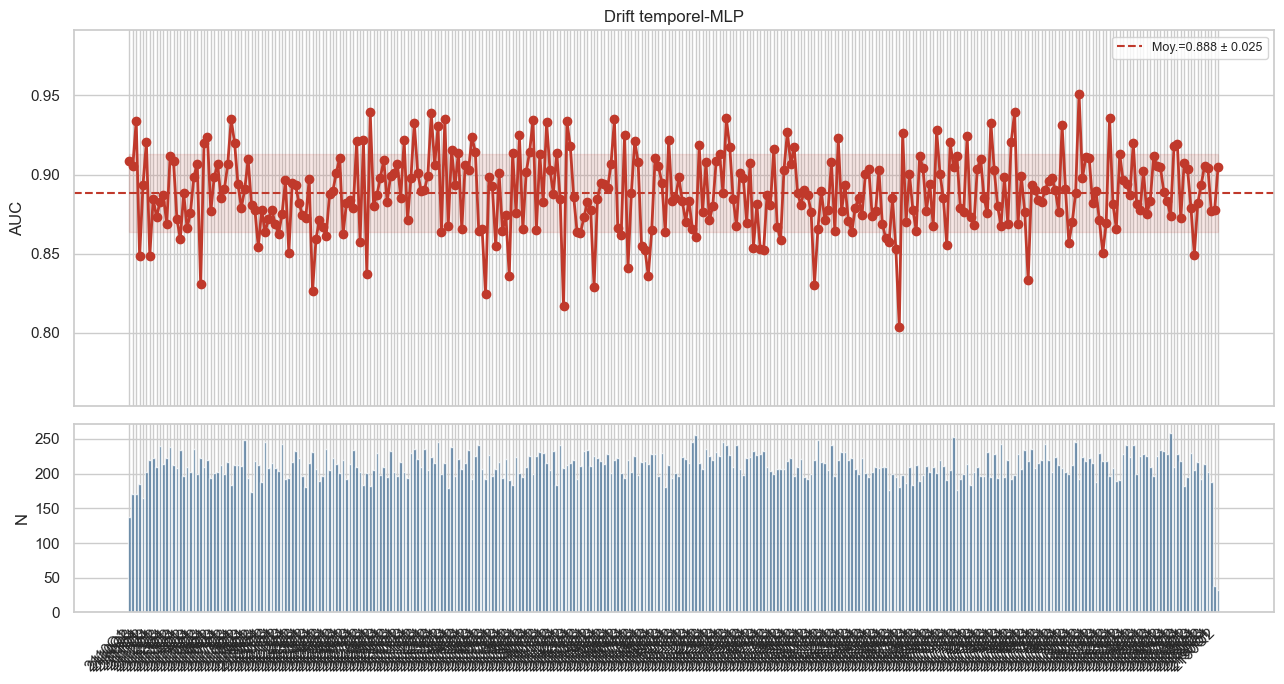

tab11_auc_trimestrielle_avec.csv sauvegardé


In [36]:
#  Stabilité temporelle par trimestre 
if 'intime' not in df_val_temp.columns:
    print('intime absent — drift non disponible')
else:
    df_drift = df_val_temp.copy()
    df_drift['intime']  = pd.to_datetime(df_drift['intime'], errors='coerce')
    df_drift['quarter'] = df_drift['intime'].dt.to_period('Q')
    df_drift['yp'] = predict_proba_safe(model, build_X(df_drift, features_baseline, scaler, tfidf, imputer, train_medians))

    rows = [{'q': str(p), 'n': len(g), 'auc': roc_auc_score(g[TARGET], g['yp'])}
            for p, g in df_drift.groupby('quarter')
            if g[TARGET].nunique() == 2 and len(g) >= 30]
    dq = pd.DataFrame(rows)

    if len(dq) == 0:
        print('Aucun trimestre exploitable pour le drift')
    else:
        x = range(len(dq))
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                        gridspec_kw={'height_ratios': [2, 1]})
        ax1.plot(x, dq['auc'], 'o-', color='#C0392B', lw=2, markersize=6)
        ax1.axhline(dq['auc'].mean(), color='#C0392B', lw=1.5, linestyle='--',
                    label=f'Moy.={dq["auc"].mean():.3f} ± {dq["auc"].std():.3f}')
        ax1.fill_between(x, dq['auc'].mean()-dq['auc'].std(),
                            dq['auc'].mean()+dq['auc'].std(), alpha=0.12, color='#C0392B')
        ax1.set_ylim(max(0.5, dq['auc'].min()-0.05), min(1.0, dq['auc'].max()+0.04))
        ax1.set_ylabel('AUC')
        ax1.set_title(f'Drift temporel-{model_type}', fontweight='normal')
        ax1.legend(fontsize=9)

        ax2.bar(x, dq['n'], color='#2E5F8A', alpha=0.75)
        ax2.set_ylabel('N')
        ax2.set_xticks(list(x))
        ax2.set_xticklabels(dq['q'], rotation=45, ha='right')

        plt.tight_layout()
        plt.savefig(FIG_DIR / 'fig16_drift_temporel_avec.png', dpi=150, bbox_inches='tight')
        plt.show()

        dq.to_csv(RESULT_DIR / 'tab11_auc_trimestrielle_avec.csv', index=False)
        print('tab11_auc_trimestrielle_avec.csv sauvegardé')


## 10. Interprétabilité


In [37]:
# Interprétabilité : approche adaptée au modèle retenu 
# On garde une stratégie robuste :
#   1. importance globale rapide sur toutes les variables ;
#   2. SHAP model-agnostic sur les variables structurées uniquement ;
#   3. importance des termes NLP à partir de l'importance globale.

for _var in ['features_baseline', 'tfidf', 'model', 'X_val', 'y_val',
             'scaler', 'imputer', 'feature_names']:
    if _var not in dir():
        raise NameError(f"'{_var}' non défini — exécuter Kernel > Run All Above.")

feature_names = features_baseline + list(tfidf.get_feature_names_out())
if X_val.shape[1] != len(feature_names):
    raise ValueError(f'X_val={X_val.shape[1]} vs feature_names={len(feature_names)}')

model_class = type(model).__name__
TFIDF_START = len(features_baseline)
rng = np.random.default_rng(RANDOM_STATE)
INTERP_MODE = 'shap'

print(f'Modèle interprété : {model_class} ({model_type})')


Modèle interprété : MLPClassifier (MLP)


In [38]:
# Étape 1 : Importance globale rapide — toutes features 
print('\nÉtape 1 — Importance globale rapide...')

if model_class in ['RandomForestClassifier', 'XGBClassifier']:
    imp = model.feature_importances_
    imp_type = 'Gini (MDI)' if model_class == 'RandomForestClassifier' else 'Gain moyen'
elif model_class == 'LogisticRegression':
    imp = np.abs(model.coef_[0])
    imp_type = '|Coefficient|'
elif model_class == 'MLPClassifier':
    # Approximation rapide : poids absolus entre la couche d'entrée et la 1re couche cachée.
    # Ce n'est pas un SHAP global ; cela sert à repérer les variables/termes les plus utilisés par le réseau.
    imp = np.mean(np.abs(model.coefs_[0]), axis=1)
    imp_type = 'Poids entrée MLP |W| - proxy descriptif'
else:
    raise ValueError(f"'{model_class}' non supporté pour l'importance globale rapide.")

if len(imp) != len(feature_names):
    raise ValueError(f'Importance={len(imp)} vs feature_names={len(feature_names)}')

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': imp,
    'type': ['NLP' if i >= TFIDF_START else 'Clinique' for i in range(len(feature_names))],
    'methode': imp_type,
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df.to_csv(RESULT_DIR / 'tab12_importance_globale_avec.csv', index=False)
print(f'  Méthode      : {imp_type}')
print(f'  Top 5 global : {importance_df["feature"].head().tolist()}')
print('tab12_importance_globale_avec.csv sauvegardé')


Étape 1 — Importance globale rapide...
  Méthode      : Poids entrée MLP |W| - proxy descriptif
  Top 5 global : ['rci', 'jaundice', 'gib', 'status fever', 'needlestick']
tab12_importance_globale_avec.csv sauvegardé


In [39]:
# Étape 2 : SHAP sur features STRUCTURÉES uniquement 
# TreeExplainer sur la matrice complète (1017 features) est trop lent.
# On calcule les valeurs SHAP sur la sous-matrice structurée uniquement.
# Méthode : PermutationExplainer (model-agnostic, pas de wrapper biaisé).
# Les features NLP sont couvertes par l'importance globale rapide (étape 1).
print('\nÉtape 2 — SHAP PermutationExplainer sur features structurées...')

N_SHAP       = min(500, X_val.shape[0])
idx_shap     = rng.choice(X_val.shape[0], size=N_SHAP, replace=False)
X_shap_full  = X_val[idx_shap].toarray() if issparse(X_val) else np.asarray(X_val[idx_shap])
X_shap_struct = X_shap_full[:, :TFIDF_START]
X_shap_df     = pd.DataFrame(X_shap_struct, columns=features_baseline)
y_shap        = np.asarray(y_val)[idx_shap]

# PermutationExplainer : perturbe chaque feature et mesure la chute de performance
# Appliqué directement sur le modèle complet via une fonction de prédiction
# qui reconstruit la matrice complète (structurées + TF-IDF zéro).
# Cela donne les SHAP marginaux corrects pour les features structurées.
def _predict_with_struct(X_struct_arr):
    """Reconstruit X complet avec TF-IDF=0 pour les features structurées seules."""
    n = X_struct_arr.shape[0]
    X_full = np.zeros((n, TFIDF_START + (X_val.shape[1] - TFIDF_START)))
    X_full[:, :TFIDF_START] = X_struct_arr
    return predict_proba_safe(model, csr_matrix(X_full))

explainer_struct = shap.Explainer(
    _predict_with_struct,
    X_shap_df,
    feature_names=features_baseline,
    algorithm='permutation',
    max_evals=2 * len(features_baseline) + 1
)
shap_out    = explainer_struct(X_shap_df)
shap_values = np.asarray(shap_out.values)
if shap_values.ndim == 3: shap_values = shap_values[:, :, 1]

feature_names_shap = features_baseline

print(f'SHAP calculé - shape : {shap_values.shape} ({N_SHAP} séjours)')
print(f'Features SHAP : {feature_names_shap}')
print('Note : importance NLP dans tab12_importance_globale_avec.csv (étape 1)')



Étape 2 — SHAP PermutationExplainer sur features structurées...


PermutationExplainer explainer: 501it [00:54,  8.45it/s]                         

SHAP calculé - shape : (500, 32) (500 séjours)
Features SHAP : ['heartrate', 'sbp', 'dbp', 'o2sat', 'resprate', 'temperature', 'pain', 'age_ed', 'acuity', 'n_hosp_anterieures', 'hour', 'day_of_week', 'charlson_score', 'cm_dm_sans_complic', 'cm_dm_avec_complic', 'cm_insuffisance_card', 'cm_bpco', 'cm_insuffisance_renale', 'cm_cancer', 'cm_cancer_meta', 'cm_infarctus', 'cm_avc', 'cm_demence', 'cm_maladie_foie', 'cm_vih_sida', 'gender_f', 'gender_m', 'arrival_transport_ambulance', 'arrival_transport_helicopter', 'arrival_transport_other', 'arrival_transport_unknown', 'arrival_transport_walk_in']
Note : importance NLP dans tab12_importance_globale_avec.csv (étape 1)


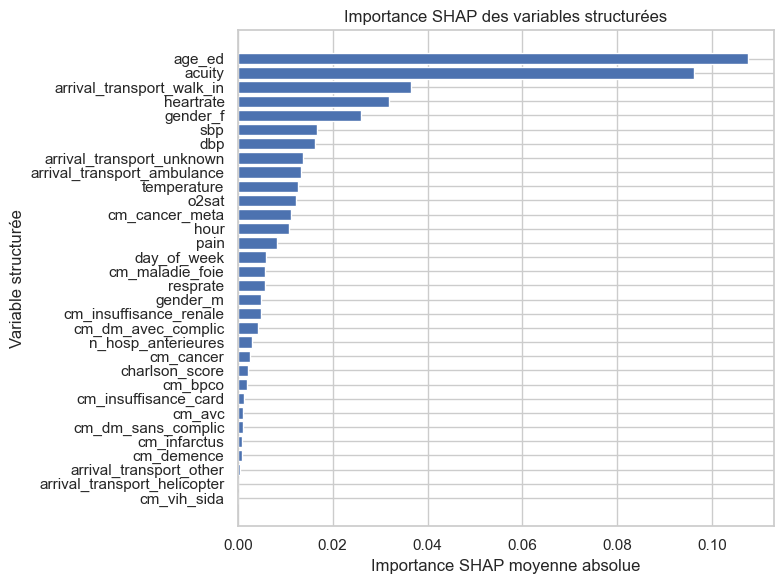

Figure sauvegardée : C:\Users\wdois\Desktop\Memoire_SDA7\figures\fig17_shap_importance_struct_avec.png


In [40]:
#  Visualisation SHAP - features structurées 
# Cette cellule utilise les valeurs SHAP déjà calculées dans la cellule précédente.


# Vérification de cohérence
assert shap_values.shape[1] == len(feature_names_shap), (
    "Le nombre de colonnes SHAP ne correspond pas au nombre de features."
)

# 1. Barplot SHAP : importance moyenne absolue des variables structurées

shap_importance = (
    pd.DataFrame({
        "Variable": feature_names_shap,
        "Importance_SHAP_moyenne": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("Importance_SHAP_moyenne", ascending=True)
)

plt.figure(figsize=(8, 6))
plt.barh(
    shap_importance["Variable"],
    shap_importance["Importance_SHAP_moyenne"]
)
plt.xlabel("Importance SHAP moyenne absolue")
plt.ylabel("Variable structurée")
plt.title("Importance SHAP des variables structurées")
plt.tight_layout()

out_bar = FIG_DIR / "fig17_shap_importance_struct_avec.png"
plt.savefig(out_bar, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure sauvegardée : {out_bar.resolve()}")


### 10.1 Importance globale


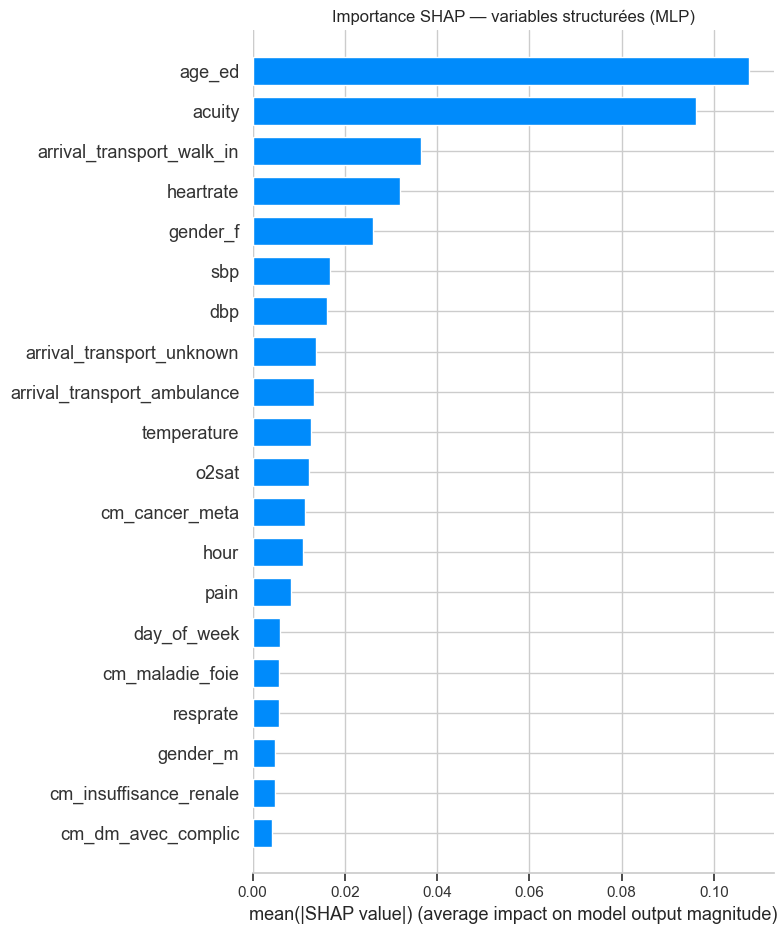

In [41]:
#  Importance SHAP des variables structurées
if INTERP_MODE == 'shap':
    plt.figure(figsize=(8,6))
    shap.summary_plot(shap_values, X_shap_df, plot_type='bar', max_display=20, show=False)
    plt.title(f'Importance SHAP — variables structurées ({model_type})', fontsize=12, fontweight='normal')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig18_shap_global_avec.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    top20 = importance_df.head(20).sort_values('importance')
    colors = ['#C0392B' if t == 'NLP' else '#2E5F8A' for t in top20['type']]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top20['feature'], top20['importance'], color=colors, edgecolor='white')
    ax.set_xlabel('Importance globale')
    ax.set_title(f'Importance globale — {model_type}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig19_importance_global_avec.png', dpi=150, bbox_inches='tight')
    plt.show()

### 10.2 Direction et magnitude


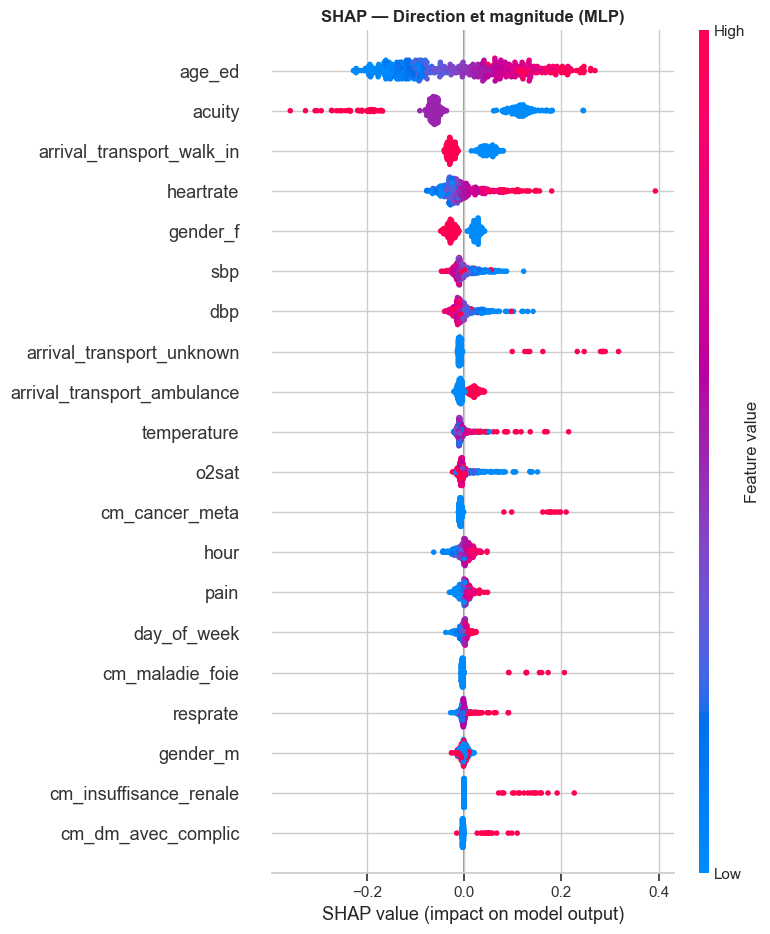

In [42]:
#  Direction et magnitude 
if INTERP_MODE == 'shap':
    plt.figure(figsize=(8,6))
    shap.summary_plot(shap_values, X_shap_df, max_display=20, show=False)
    plt.title(f'SHAP — Direction et magnitude ({model_type})', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig20_shap_density_avec.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Direction SHAP non calculée pour ce modèle non linéaire.')
    print('Pour le MLP, le notebook utilise une importance globale par permutation.')


### 10.3 Top termes NLP


In [43]:
#  Top termes NLP
# shap_values couvre les variables structurées ; l'importance des termes NLP
# vient de l'importance globale rapide calculée à l'étape 1.
top_nlp = (
    importance_df[importance_df['type'] == 'NLP']
    [['feature', 'importance', 'methode']]
    .rename(columns={'feature': 'Terme', 'importance': 'Importance', 'methode': 'Méthode'})
    .assign(Contribution_moyenne=np.nan)  # signe non disponible pour cette importance globale
    .sort_values('Importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print('=== Top 15 termes NLP les plus influents ===')
display(top_nlp)
top_nlp.to_csv(RESULT_DIR / 'tab13_top_termes_nlp_avec.csv', index=False)
print('tab13_top_termes_nlp_avec.csv sauvegardé')

=== Top 15 termes NLP les plus influents ===


,Terme,Importance,Méthode,Contribution_moyenne
0,rci,0.233499,Poids entrée MLP |W| - proxy descriptif,NaN
1,jaundice,0.227463,Poids entrée MLP |W| - proxy descriptif,NaN
2,gib,0.223405,Poids entrée MLP |W| - proxy descriptif,NaN
3,status fever,0.222935,Poids entrée MLP |W| - proxy descriptif,NaN
4,needlestick,0.221303,Poids entrée MLP |W| - proxy descriptif,NaN
5,appendicitis,0.221071,Poids entrée MLP |W| - proxy descriptif,NaN
6,pancreatitis,0.219867,Poids entrée MLP |W| - proxy descriptif,NaN
7,sepsis,0.212698,Poids entrée MLP |W| - proxy descriptif,NaN
8,pain anxiety,0.193825,Poids entrée MLP |W| - proxy descriptif,NaN
9,mvc pain,0.190117,Poids entrée MLP |W| - proxy descriptif,NaN


tab13_top_termes_nlp_avec.csv sauvegardé


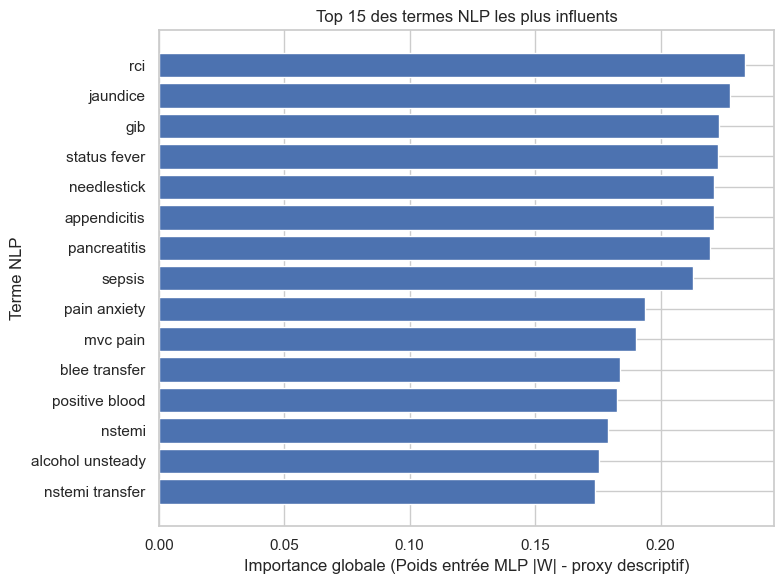

In [44]:
#  Figure : Top termes NLP selon l'importance globale
# Utilise le tableau top_nlp déjà créé ci-dessus.
FIG_DIR.mkdir(parents=True, exist_ok=True)

top_nlp_plot = top_nlp.sort_values("Importance", ascending=True)
methode_nlp = top_nlp["Méthode"].iloc[0] if len(top_nlp) > 0 else "Importance globale"

plt.figure(figsize=(8, 6))

plt.barh(
    top_nlp_plot["Terme"],
    top_nlp_plot["Importance"]
)

plt.xlabel(f"Importance globale ({methode_nlp})")
plt.ylabel("Terme NLP")
plt.title("Top 15 des termes NLP les plus influents")

plt.tight_layout()

out_path = FIG_DIR / "fig21_top15_termes_nlp_avec.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

#print(f"Figure sauvegardée : {out_path.resolve()}")


### 10.4 Explication locale — patient individuel


Motif de consultation : confusion hallucination
P(hospit.) = 71.35% | Réel : 1


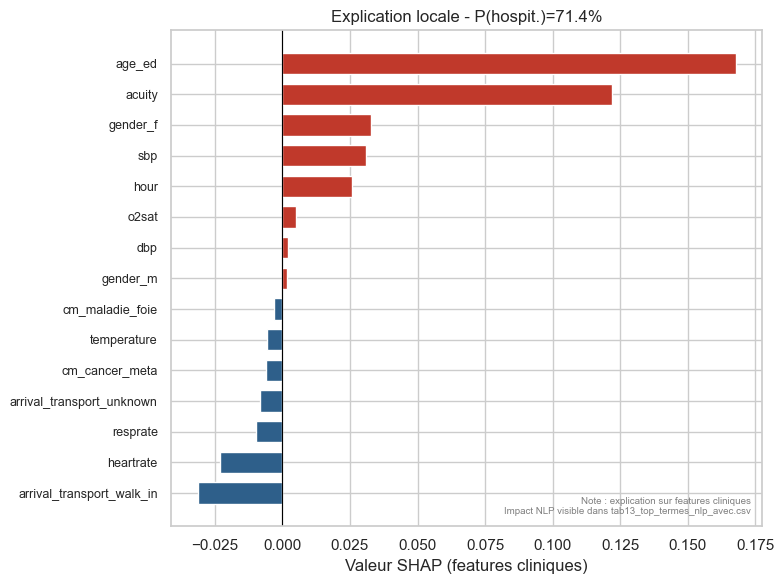

In [45]:
# Explication locale d'un patient hospitalisé 
idx_hosp   = df_val_temp[df_val_temp[TARGET] == 1].index[0]
patient_row = df_val_temp.loc[[idx_hosp]]
X_patient   = build_X(patient_row, features_baseline, scaler, tfidf, imputer, train_medians)
prob_hosp   = predict_proba_safe(model, X_patient)[0]

print(f'Motif de consultation : {patient_row["cleaned_complaint"].values[0]}')
print(f'P(hospit.) = {prob_hosp:.2%} | Réel : {patient_row[TARGET].values[0]}')

# Explication locale sur les features structurées via explainer_struct
# (même explainer que l'étape 2 — features cliniques uniquement)
X_patient_arr    = X_patient.toarray() if issparse(X_patient) else np.asarray(X_patient)
X_patient_struct = X_patient_arr[:, :TFIDF_START]
X_patient_df     = pd.DataFrame(X_patient_struct, columns=feature_names_shap)

patient_shap = explainer_struct(X_patient_df).values
patient_shap = np.asarray(patient_shap)
if patient_shap.ndim == 3: patient_shap = patient_shap[:, :, 1]

local_s = pd.Series(patient_shap[0], index=feature_names_shap)
xlabel  = 'Valeur SHAP (features cliniques)'

top15  = local_s.reindex(local_s.abs().nlargest(15).index).sort_values()
colors = ['#C0392B' if v > 0 else '#2E5F8A' for v in top15.values]

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(range(len(top15)), top15.values, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([n if len(n) <= 32 else n[:30] + '…' for n in top15.index], fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel(xlabel)
ax.set_title(f'Explication locale - P(hospit.)={prob_hosp:.1%}', fontweight='normal')
ax.text(0.98, 0.02,
        f'Note : explication sur features cliniques\nImpact NLP visible dans tab13_top_termes_nlp_avec.csv',
        transform=ax.transAxes, fontsize=7, ha='right', va='bottom', color='grey')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig22_interpretation_locale_avec.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Analyses complémentaires


In [46]:
# Analyse des sous-groupes d'âge
AGE_COL = 'age_ed' if 'age_ed' in df_val_temp.columns else 'anchor_age'
age_groups = [(18, 45, '18-44 ans'), (45, 65, '45-64 ans'),
              (65, 75, '65-74 ans'), (75, 200, '≥75 ans')]

# seuil_alerte et seuil_fort ont été fixés sur la validation interne.
print(f'Seuil alerte figé : {seuil_alerte:.3f}')
print(f'Seuil fort figé   : {seuil_fort:.3f}')

def classer_risque(p):
    if p >= seuil_fort:
        return '\U0001F534 Élevé'    
    if p >= seuil_alerte:
        return '\U0001F7E0 Modéré'   
    return '\U0001F7E2 Faible'       
    
subgroups = {}
for lo, hi, label in age_groups:
    mask = (df_val_temp[AGE_COL] >= lo) & (df_val_temp[AGE_COL] < hi)
    if mask.sum() >= 30 and len(np.unique(y_val[mask.values])) == 2:
        X_ = build_X(df_val_temp[mask], features_baseline, scaler, tfidf, imputer, train_medians)
        yp_ = predict_proba_safe(model, X_)
        y_ = y_val[mask.values]
        pred_ = (yp_ >= seuil_alerte).astype(int)
        tn_, fp_, fn_, tp_ = confusion_matrix(y_, pred_).ravel()
        subgroups[label] = {
            'n': int(mask.sum()),
            'AUC': round(roc_auc_score(y_, yp_), 4),
            'Brier': round(brier_score_loss(y_, yp_), 4),
            'Se_seuil_alerte': round(tp_/(tp_+fn_) if (tp_+fn_) else 0, 4),
            'Sp_seuil_alerte': round(tn_/(tn_+fp_) if (tn_+fp_) else 0, 4),
            'FN': int(fn_),
            'Taux_FN_hospitalisés': round(fn_/(tp_+fn_) if (tp_+fn_) else 0, 4),
            'P_hospit': round(yp_.mean(), 4),
        }

sg_df = pd.DataFrame(subgroups).T.reset_index().rename(columns={'index': 'Tranche'})
sg_df['AUC_global'] = round(auc, 4)
sg_df['Δ_vs_global'] = (sg_df['AUC'] - auc).round(4)
sg_df['Alerte'] = sg_df['P_hospit'].apply(classer_risque)

display(sg_df.sort_values('P_hospit', ascending=False))
sg_df.to_csv(RESULT_DIR / 'tab14_subgroup_age_avec.csv', index=False)
print('tab14_subgroup_age_avec.csv sauvegardé')


Seuil alerte figé : 0.241
Seuil fort figé   : 0.650


,Tranche,n,AUC,Brier,Se_seuil_alerte,Sp_seuil_alerte,FN,Taux_FN_hospitalisés,P_hospit,AUC_global,Δ_vs_global,Alerte
3,≥75 ans,9784.0,0.8294,0.1483,0.9743,0.2471,177.0,0.0257,0.6920,0.8881,-0.0587,🔴 Élevé
2,65-74 ans,8795.0,0.8475,0.1550,0.9545,0.4186,238.0,0.0455,0.5823,0.8881,-0.0406,🟠 Modéré
1,45-64 ans,18697.0,0.8555,0.1537,0.9013,0.5685,827.0,0.0987,0.4364,0.8881,-0.0326,🟠 Modéré
0,18-44 ans,30687.0,0.8640,0.1056,0.7248,0.8254,1639.0,0.2752,0.1893,0.8881,-0.0241,🟢 Faible


tab14_subgroup_age_avec.csv sauvegardé


In [47]:
# Faux négatifs au seuil clinique figé
fn_mask = (y_val == 1) & (y_pred == 0)
fn_df   = df_val_temp[fn_mask].copy()

n_fn    = int(fn_mask.sum())
n_hosp  = int((y_val == 1).sum())
n_total = int(len(y_val))

print(f'FN au seuil clinique={seuil_alerte:.3f} : {n_fn:,} / {n_hosp:,} hospitalisations '
      f'({n_fn/n_hosp*100:.1f}% des hospitalisations)')
print(f'Soit {n_fn/n_total*100:.1f}% de la cohorte totale')
AGE_COL = 'age_ed' if 'age_ed' in fn_df.columns else 'anchor_age'
print(f'Âge médian FN ({AGE_COL}) : {fn_df[AGE_COL].median():.0f} ans')

CHARLSON_COL = 'charlson_score' if 'charlson_score' in fn_df.columns else 'charlson_score_simplifie'
if CHARLSON_COL in fn_df.columns:
    print(f'{CHARLSON_COL} médian : {fn_df[CHARLSON_COL].median():.1f}')
if 'acuity' in fn_df.columns:
    print(f'Distribution ESI :\n{fn_df["acuity"].value_counts().sort_index().to_string()}')

print(f'\nTop 10 motifs FN :')
print(fn_df["cleaned_complaint"].value_counts().head(10).to_string())


FN au seuil clinique=0.241 : 2,881 / 26,453 hospitalisations (10.9% des hospitalisations)
Soit 4.2% de la cohorte totale
Âge médian FN (age_ed) : 39 ans
charlson_score médian : 0.0
Distribution ESI :
acuity
1.0      30
2.0     576
3.0    2194
4.0      77
5.0       3

Top 10 motifs FN :
cleaned_complaint
chest pain            101
abdominal pain         70
headache               62
rlq abdominal pain     54
flank pain             51
wound eval             46
chest pain dyspnea     45
low pain               44
pain                   39
palpitation            33


## 12. Diagnostic du terme « transfer »


In [48]:
# Diagnostic du terme 'transfer'
# Objectif : documenter le signal apporté par ce terme dans les motifs de consultation.
# Dans un usage opérationnel de réservation de lits, il peut être légitime s'il est disponible dès l'arrivée.
# Il reste cependant utile de le comparer au modèle sans ce terme dans la Partie 2.

if 'cleaned_complaint' in df_val_temp.columns:
    mask_transfer = df_val_temp['cleaned_complaint'].str.contains(r'\btransfer\b', case=False, na=False, regex=True)
    n = int(mask_transfer.sum())
    taux = df_val_temp.loc[mask_transfer, TARGET].mean() if n > 0 else np.nan
    taux_sans = df_val_temp.loc[~mask_transfer, TARGET].mean() if (~mask_transfer).sum() > 0 else np.nan

    print("Terme 'transfer' dans cleaned_complaint — validation temporelle :")
    print(f"  Séjours avec 'transfer' : {n:,} ({n/len(df_val_temp)*100:.1f}%)")
    print(f"  Taux hospit. avec 'transfer' : {taux:.1%}" if not np.isnan(taux) else "  Taux hospit. avec 'transfer' : non calculable")
    print(f"  Taux hospit. sans 'transfer' : {taux_sans:.1%}" if not np.isnan(taux_sans) else "  Taux hospit. sans 'transfer' : non calculable")
    print(f"  Taux hospit. global          : {y_val.mean():.1%}")

    if n > 0 and (~mask_transfer).sum() > 30:
        auc_transfer = roc_auc_score(y_val[mask_transfer.values], y_proba[mask_transfer.values]) \
            if df_val_temp.loc[mask_transfer, TARGET].nunique() == 2 else np.nan
        auc_sans_transfer = roc_auc_score(y_val[(~mask_transfer).values], y_proba[(~mask_transfer).values]) \
            if df_val_temp.loc[~mask_transfer, TARGET].nunique() == 2 else np.nan
        print(f"  AUC sur séjours avec 'transfer' : {auc_transfer:.4f}" if not np.isnan(auc_transfer) else "  AUC avec transfer : non calculable")
        print(f"  AUC sur séjours sans 'transfer' : {auc_sans_transfer:.4f}" if not np.isnan(auc_sans_transfer) else "  AUC sans transfer : non calculable")

    if n > 0:
        table_transfer = pd.DataFrame({
            'groupe': ['Avec transfer', 'Sans transfer'],
            'n': [int(mask_transfer.sum()), int((~mask_transfer).sum())],
            'taux_hospitalisation': [taux, taux_sans],
        })
        table_transfer.to_csv(RESULT_DIR / 'tab15_diagnostic_transfer_avec.csv', index=False)
        display(table_transfer)

        cols_show = [c for c in ['chiefcomplaint', 'cleaned_complaint', TARGET, 'acuity'] if c in df_val_temp.columns]
        display(df_val_temp.loc[mask_transfer, cols_show].head(10))
else:
    print("cleaned_complaint absent — diagnostic transfer non disponible")


Terme 'transfer' dans cleaned_complaint — validation temporelle :
  Séjours avec 'transfer' : 9,446 (13.9%)
  Taux hospit. avec 'transfer' : 81.1%
  Taux hospit. sans 'transfer' : 32.1%
  Taux hospit. global          : 38.9%
  AUC sur séjours avec 'transfer' : 0.8033
  AUC sur séjours sans 'transfer' : 0.8715


,groupe,n,taux_hospitalisation
0,Avec transfer,9446,0.811455
1,Sans transfer,58517,0.321069


,cleaned_complaint,target,acuity
108,headache transfer,1,2.0
116,lethargy transfer,1,2.0
200,fall transfer,1,2.0
237,abscess transfer,0,3.0
271,fever jaundice transfer,1,2.0
345,sdh syncope transfer,1,2.0
513,abdominal pain transfer,1,2.0
540,bradycardia transfer,1,1.0
546,chest pain transfer,1,2.0
568,abnormal lab transfer,0,2.0


## 13. Export des résultats-clés et sauvegarde finale


In [49]:
# ── Export des résultats-clés vers resultats_cles.json ──
# La prose du mémoire peut lire ces clés.
_path_res = RESULT_DIR / 'resultats_cles.json'
_res = {}
if Path(_path_res).exists():
    with open(_path_res, encoding='utf-8') as _f:
        _res = _json.load(_f)

def _num(x):
    try:
        x = float(x)
        return None if _math.isnan(x) else x
    except (TypeError, ValueError):
        return None

# Clés toujours disponibles (métriques de validation temporelle)
_res.update({
    'modele_retenu':       model_type,
    'auc_validation_temp': round(_num(auc), 4),
    'sensibilite_seuil':   round(_num(sensibilite), 4),
    'specificite_seuil':   round(_num(specificite), 4),
    'seuil_alerte':        round(_num(seuil_alerte), 3),
})

# Clés du sous-groupe 'transfer' - seulement si le diagnostic les a produites
_n   = globals().get('n')
_tx  = globals().get('taux')
_at  = _num(globals().get('auc_transfer'))
_ast = _num(globals().get('auc_sans_transfer'))
if _n is not None:
    _res['transfer_n']         = int(_n)
    _res['transfer_pct']       = round(int(_n) / len(df_val_temp) * 100, 1)
    _res['transfer_taux_hosp'] = round(float(_tx) * 100, 1) if _tx is not None else None
if _at is not None:
    _res['auc_avec_transfer']  = round(_at, 4)
if _ast is not None:
    _res['auc_sans_transfer']  = round(_ast, 4)

with open(_path_res, 'w', encoding='utf-8') as _f:
    _json.dump(_res, _f, ensure_ascii=False, indent=2)
print(f'{_path_res.name} mis à jour ({len(_res)} clés) :')
for _k, _v in _res.items():
    print(f'{_k:<22}: {_v}')

# Phrase 'transfer' prête à coller, si les valeurs existent
if _res.get('auc_avec_transfer') is not None and _res.get('transfer_n') is not None:
    _n_fmt = f"{_res['transfer_n']:,}".replace(',', ' ')
    print('\n' + (
        f"Le terme « transfer » concerne {_n_fmt} séjours ({_res['transfer_pct']} %), "
        f"hospitalisés dans {_res['transfer_taux_hosp']} % des cas. "
        f"L'AUC y est plus basse ({_res['auc_avec_transfer']:.3f}) que sur les séjours sans ce terme "
        f"({_res['auc_sans_transfer']:.3f}), du fait de l'homogénéité du sous-groupe."
    ))


resultats_cles.json mis à jour (10 clés) :
modele_retenu         : MLP
auc_validation_temp   : 0.8881
sensibilite_seuil     : 0.8911
specificite_seuil     : 0.6862
seuil_alerte          : 0.241
transfer_n            : 9446
transfer_pct          : 13.9
transfer_taux_hosp    : 81.1
auc_avec_transfer     : 0.8033
auc_sans_transfer     : 0.8715

Le terme « transfer » concerne 9 446 séjours (13.9 %), hospitalisés dans 81.1 % des cas. L'AUC y est plus basse (0.803) que sur les séjours sans ce terme (0.872), du fait de l'homogénéité du sous-groupe.


In [50]:
# Sauvegarde finale des artefacts et des tableaux principaux
# Toutes les sauvegardes principales sont regroupées ici pour éviter l'impression
# de deux notebooks fusionnés.

# Enrichissement des métadonnées avec les résultats temporels disponibles.
if 'auc' in globals():
    meta.update({
        'auc_validation_temporelle': float(auc),
        'sensibilite_validation_temporelle': float(sensibilite),
        'specificite_validation_temporelle': float(specificite),
        'vpp_validation_temporelle': float(vpp) if 'vpp' in globals() else None,
        'vpn_validation_temporelle': float(vpn) if 'vpn' in globals() else None,
        'brier_validation_temporelle': float(brier) if 'brier' in globals() else None,
        'ece_validation_temporelle': float(ece) if 'ece' in globals() else None,
        'average_precision_validation_temporelle': float(ap) if 'ap' in globals() else None,
        'calibration_used_as_final': False,
        'nb07_alignment': 'NB03 exporte les mêmes prédictions et tableaux opérationnels que NB07 ; NB07 doit reconstruire les dummies catégorielles à partir de gender et arrival_transport.',
    })
if 'n' in globals():
    meta.update({
        'transfer_n_validation_temporelle': int(n),
        'transfer_pct_validation_temporelle': float(n / len(df_val_temp) * 100),
        'transfer_taux_hospitalisation': float(taux) if 'taux' in globals() and pd.notna(taux) else None,
        'sans_transfer_taux_hospitalisation': float(taux_sans) if 'taux_sans' in globals() and pd.notna(taux_sans) else None,
    })

_artefacts_requis = {
    'model_m3_opt': MODEL_DIR / 'best_model.pkl',
    'scaler_m3': MODEL_DIR / 'best_scaler.pkl',
    'feats_m3': MODEL_DIR / 'best_features.pkl',
    'imputer': MODEL_DIR / 'best_imputer.pkl',
    'tfidf': MODEL_DIR / 'tfidf_vectorizer.pkl',
    'model_rl_m3_base': MODEL_DIR / 'model_rl_base.pkl',
}

for var_name, path in _artefacts_requis.items():
    obj = locals().get(var_name)
    if obj is None:
        print(f'{var_name} non défini — sauvegarde ignorée : {path.name}')
        continue
    joblib.dump(obj, path)
    print(f'{path.name}')

with open(MODEL_DIR / 'model_metadata.json', 'w', encoding='utf-8') as f:
    _json.dump(meta, f, indent=2, ensure_ascii=False)
print('model_metadata.json')

# Tableaux principaux de comparaison et de sélection.
results_df.to_csv(RESULT_DIR / 'tab16_comparaison_modeles_base_avec.csv', index=False)
df_m3_base.to_csv(RESULT_DIR / 'tab17_comparaison_m3_base_avec.csv', index=False)
df_m3_base_05.to_csv(RESULT_DIR / 'tab18_comparaison_m3_seuil05_avec.csv', index=False)
df_m3_selection.to_csv(RESULT_DIR / 'tab19_selection_clinique_m3_avec.csv', index=False)
metrics_final.to_csv(RESULT_DIR / 'metrics_meilleur_modele.csv', index=False)

# Alias simples pour les notebooks aval.
df_m3_base_05.to_csv(RESULT_DIR / 'tab20_comparaison_finaux_seuil05_avec.csv', index=False)
df_m3_selection.to_csv(RESULT_DIR / 'tab21_selection_clinique_finaux_avec.csv', index=False)

print('Sauvegardes finales terminées')


best_model.pkl
best_scaler.pkl
best_features.pkl
best_imputer.pkl
tfidf_vectorizer.pkl
model_rl_base.pkl
model_metadata.json
Sauvegardes finales terminées


In [51]:
print('=' * 65)
print('RÉSUMÉ FINAL — Notebook 03')
print('=' * 65)
print(f'  Train                  : {len(df_train):,} séjours')
print(f'  Validation interne     : {len(df_val):,} séjours')
print(f'  Test interne           : {len(df_test):,} séjours')
print(f'  Validation temporelle  : {len(df_valid_temp):,} séjours')
print()
print(f'  Modèle principal       : Modèle 3 — Variables structurées NB01 + NLP avec le terme transfer')
print(f'  Algorithme retenu      : {algo_opt}')
print(f'  AUC validation interne : {best_row_opt["AUC"]:.4f}')
print(f'  AUC test interne       : {auc_final:.4f}')
print(f'  AUC validation temp.   : {auc:.4f}' if 'auc' in globals() else '  AUC validation temp.   : non calculée')
print(f'  Brier test interne     : {brier_final:.4f}')
print(f'  Brier validation temp. : {brier:.4f}' if 'brier' in globals() else '  Brier validation temp. : non calculé')
print(f'  ECE validation temp.   : {ece:.4f}' if 'ece' in globals() else '  ECE validation temp.   : non calculé')
print(f'  Seuil alerte           : {seuil_alerte:.3f}  (Se ≥ 90% sur validation interne)')
print(f'  Seuil fort             : {seuil_fort:.3f}')
print()
print('Fichiers principaux sauvegardés :')
for f in ['best_model.pkl', 'model_rl_base.pkl', 'best_scaler.pkl',
          'best_features.pkl', 'best_imputer.pkl', 'tfidf_vectorizer.pkl',
          'model_metadata.json']:
    print(f'  models/{f}')
for f in ['tab16_comparaison_modeles_base_avec.csv',
          'tab17_comparaison_m3_base_avec.csv',
          'tab19_selection_clinique_m3_avec.csv',
          'metrics_meilleur_modele.csv',
          'metrics_validation_temporelle.csv',
          'resultats_cles.json',
          'tab6_validation_predictions_op_avec.csv',
          'tables/tab8_resume_seuils_op_avec.csv']:
    print(f'  results/{f}')
print()
print('Notebook 03 terminé')


RÉSUMÉ FINAL — Notebook 03
  Train                  : 203,376 séjours
  Validation interne     : 50,067 séjours
  Test interne           : 62,513 séjours
  Validation temporelle  : 67,963 séjours

  Modèle principal       : Modèle 3 — Variables structurées NB01 + NLP avec le terme transfer
  Algorithme retenu      : MLP
  AUC validation interne : 0.8605
  AUC test interne       : 0.8624
  AUC validation temp.   : 0.8881
  Brier test interne     : 0.1458
  Brier validation temp. : 0.1313
  ECE validation temp.   : 0.0091
  Seuil alerte           : 0.241  (Se ≥ 90% sur validation interne)
  Seuil fort             : 0.650

Fichiers principaux sauvegardés :
  models/best_model.pkl
  models/model_rl_base.pkl
  models/best_scaler.pkl
  models/best_features.pkl
  models/best_imputer.pkl
  models/tfidf_vectorizer.pkl
  models/model_metadata.json
  results/tab16_comparaison_modeles_base_avec.csv
  results/tab17_comparaison_m3_base_avec.csv
  results/tab19_selection_clinique_m3_avec.csv
  result